In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
import xgboost as xgb 
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from src.balance import split_data_nested_cv_ts, split_data, drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, ensemble_sample_and_merge

In [2]:
SEED = 42
TOP_FEATURES = 10

In [3]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES_NO_FILTERS, all_features=False)
dataclass.read()
# df = dataclass.preprocess()  # Assume this keeps mouse IDs for splitting
# df.to_csv('preprocessed.csv', index=False)

df = dataclass.df

# Hyperparameter grid for XGBClassifier
param_grid = {
    'xgbclassifier__n_estimators': [100, 500, 1000],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__subsample': [0.7, 0.8, 1.0]
}

def expanding_window_split(df, n_splits=4):
    """
    Perform Expanding Window Split

    Args:
        df (pd.DataFrame): DataFrame containing all instances, sorted by time.
        n_splits (int): Number of splits for expanding windows.

    Returns:
        splits (dict): Dictionary with train-test-validation splits for each fold.
    """
    splits = {}

    # Sort the DataFrame by 'day_of_study' to ensure chronological order
    df = df.sort_values(by='day_of_study').reset_index(drop=True)

    # TimeSeriesSplit for expanding window
    tscv = TimeSeriesSplit(n_splits=n_splits)
    for i, (train_indices, test_indices) in enumerate(tscv.split(df)):
        
        # Prepare training, validation, and testing sets
        X_train = df.iloc[train_indices].drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_train = df.iloc[train_indices]['group_name'].reset_index(drop=True)

        # Test data
        X_test = df.iloc[test_indices].drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_test = df.iloc[test_indices]['group_name'].reset_index(drop=True)

        # Store splits
        splits[i] = {
            'X_train': X_train,
            'y_train': y_train,
            'X_test': X_test,
            'y_test': y_test
        }
    
    return splits

# Apply expanding window split with oversampling
m_data = expanding_window_split(df)



Fold 0:
Original train class distribution: Counter({0: 64, 1: 14})
Original test class distribution: Counter({0: 61, 1: 15})
Best parameters for fold 0: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.7}

Fold 0 results:
Accuracy: 0.8421
F1-macro: 0.6811
F1-micro: 0.8421
F1-weighted: 0.8183
Precision: 0.7143
Recall: 0.3333
ROC AUC: 0.6546
True Positives: 5, False Negatives: 10, False Positives: 2, True Negatives: 59


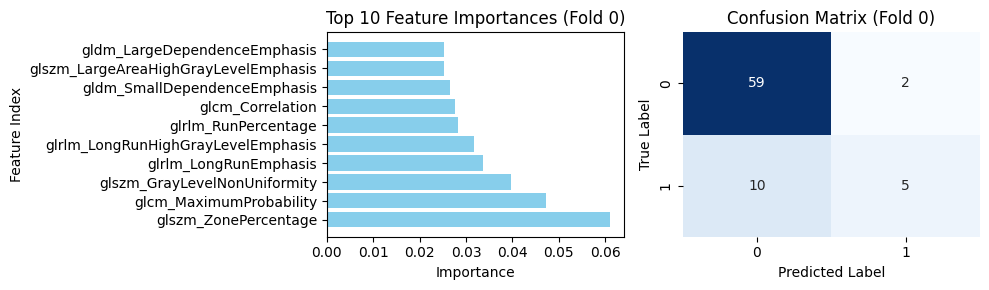


Fold 1:
Original train class distribution: Counter({0: 125, 1: 29})
Original test class distribution: Counter({0: 58, 1: 18})
Best parameters for fold 1: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 1.0}

Fold 1 results:
Accuracy: 0.7632
F1-macro: 0.6946
F1-micro: 0.7632
F1-weighted: 0.7708
Precision: 0.5000
Recall: 0.6111
ROC AUC: 0.8285
True Positives: 11, False Negatives: 7, False Positives: 11, True Negatives: 47


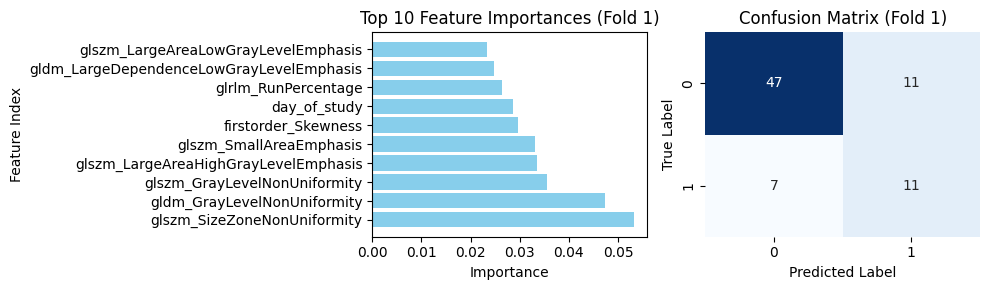


Fold 2:
Original train class distribution: Counter({0: 183, 1: 47})
Original test class distribution: Counter({0: 61, 1: 15})
Best parameters for fold 2: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 2 results:
Accuracy: 0.7237
F1-macro: 0.6378
F1-micro: 0.7237
F1-weighted: 0.7446
Precision: 0.3750
Recall: 0.6000
ROC AUC: 0.7705
True Positives: 9, False Negatives: 6, False Positives: 15, True Negatives: 46


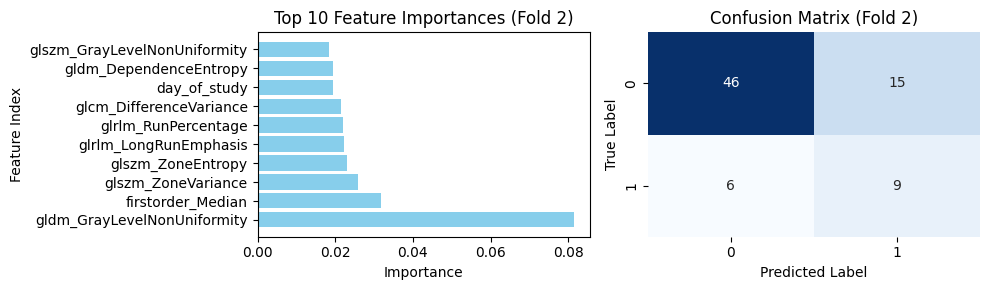


Fold 3:
Original train class distribution: Counter({0: 244, 1: 62})
Original test class distribution: Counter({0: 72, 1: 4})
Best parameters for fold 3: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.7}

Fold 3 results:
Accuracy: 0.9211
F1-macro: 0.6789
F1-micro: 0.9211
F1-weighted: 0.9284
Precision: 0.3333
Recall: 0.5000
ROC AUC: 0.8819
True Positives: 2, False Negatives: 2, False Positives: 4, True Negatives: 68


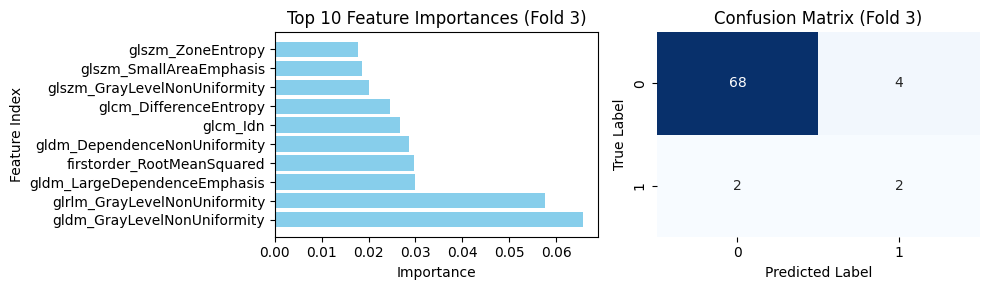


All Folds Completed.

--------------------------------------------------

Summary of Results:



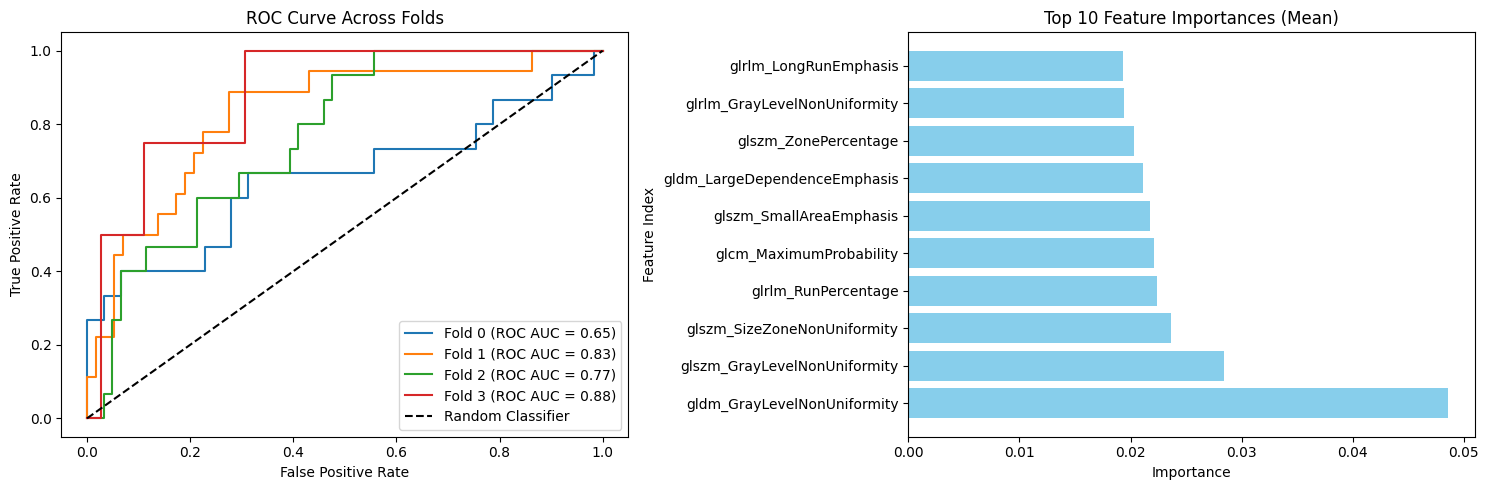


Summary Across Folds:
Mean accuracy: 0.8125
Mean F1-macro: 0.6731
Mean F1-micro: 0.8125
Mean F1-weighted: 0.8155
Mean precision: 0.4807
Mean recall: 0.5111
Mean ROC AUC: 0.7839


In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler

# Track results for each fold
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_pr_aucs, fold_f1_micros, fold_f1_weighted, feature_importances = [], [], [], [], [], [], [], [], []
class_metrics = {'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Store ROC and PR curve points for all folds
roc_curves = []
pr_curves = []

split_0_data = next(iter(m_data.values()))
# print(split_0_data['X_train'].columns)

feature_names = split_0_data['X_train'].columns  # This will be a pandas.Index
feature_names = feature_names.str.replace('original_', '', regex=False)

for fold, split_data in m_data.items():
    print(f"\nFold {fold}:")
    print(f"Original train class distribution: {Counter(split_data['y_train'])}")
    print(f"Original test class distribution: {Counter(split_data['y_test'])}")

    model = Pipeline([
        ('scaler', StandardScaler()), 
        ('smote', SMOTE(random_state=SEED)),
        ('xgbclassifier', xgb.XGBClassifier(random_state=SEED)),
    ])

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(split_data['X_train'], split_data['y_train'])

    best_model = grid_search.best_estimator_
    print(f"Best parameters for fold {fold}: {grid_search.best_params_}")

    # Extract feature importances from XGBoost
    xgb_model = best_model.named_steps['xgbclassifier']
    importances = xgb_model.feature_importances_

    # Evaluate on the test set
    preds = best_model.predict(split_data['X_test'])
    preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class
    
    # Calculate metrics
    accuracy = accuracy_score(split_data['y_test'], preds)
    f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    f1_micro = f1_score(split_data['y_test'], preds, average='micro')
    f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
    precision = precision_score(split_data['y_test'], preds)
    recall = recall_score(split_data['y_test'], preds)

    fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)

    # precision_c, recall_c, _ = precision_recall_curve(split_data['y_test'], preds_proba, pos_label=1)
    # pr_auc = average_precision_score(split_data['y_test'], preds_proba)
    
    roc_curves.append((fpr, tpr))
    # pr_curves.append((precision_c, recall_c))

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()

    # Print fold results
    print(f"\nFold {fold} results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"F1-micro: {f1_micro:.4f}")
    print(f"F1-weighted: {f1_weighted:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    # print(f"PR AUC: {pr_auc:.4f}")
    print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
    
    # Plot top k features for this fold
    top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
    top_importances = importances[top_indices]
    # print(top_importances)
    # print(top_indices)
    # print(feature_names[top_indices])

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
    plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
    plt.ylabel("Feature Index")
    plt.xlabel("Importance")
    plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
    # Plot confusion matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(split_data['y_test'], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix (Fold {fold})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # Track results
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_f1_micros.append(f1_micro)
    fold_f1_weighted.append(f1_weighted)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_roc_aucs.append(roc_auc)
    feature_importances.append(importances)
    # fold_pr_aucs.append(pr_auc)

    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

print(f"\nAll Folds Completed.")
print("\n--------------------------------------------------")
print("\nSummary of Results:\n")

# print(feature_importances)

# Plotting ROC and Precision-Recall curves side by side
plt.figure(figsize=(15, 5))

# ROC Curve Plot
plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
for i, (fpr, tpr) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.title("ROC Curve Across Folds")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Calculate mean importances across folds
mean_importances = np.mean(feature_importances, axis=0)
# print(mean_importances)
# Get indices of the top k features by mean
top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
top_importances_mean = mean_importances[top_indices_mean]
# print(top_indices_mean)
# print(top_importances_mean)
# print(feature_names[top_indices_mean])

plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
plt.ylabel("Feature Index")
plt.xlabel("Importance")
plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

# Precision-Recall Curve Plot
# plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
# for i, (precision, recall) in enumerate(pr_curves):
#     plt.plot(recall, precision, label=f'Fold {i} (PR AUC = {fold_pr_aucs[i]:.2f})')
# plt.title("Precision-Recall Curve Across Folds")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.legend(loc="lower right")

# Display the plots side by side
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

# Display summary statistics across folds
print(f"\nSummary Across Folds:")
print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
print(f"Mean precision: {np.mean(fold_precisions):.4f}")
print(f"Mean recall: {np.mean(fold_recalls):.4f}")
print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")
# print(f"Mean PR AUC: {np.mean(fold_pr_aucs):.4f}")

In [33]:
# from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import xgboost as xgb

# # Step 1: Load and preproces the data
# dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES_NO_FILTERS, all_features=False)
# dataclass.read()
# df = dataclass.preprocess(remove_mice_id=False, start_col=3)  # Keep mouse ID for the later splits

# Save the preprocessed data to a file
# df.to_csv('preprocessed.csv', index=False)


from imblearn.over_sampling import SMOTE
from collections import Counter

def split_data_population_informed(df, n_splits=4, test_size=0.6):
    """
    Perform population-informed nested cross-validation.

    Args:
        df (pd.DataFrame): The dataset with instances and metadata.
        n_splits (int): Number of splits for the outer loop.
        test_size (float): Proportion of groups used for testing.

    Returns:
        splits (dict): Dictionary containing training, validation, and test sets.
    """
    np.random.seed(SEED)
    splits = {}
    group_ids = df['m_id'].unique()
    total_groups = len(group_ids)
    test_groups_count = max(1, int(total_groups * test_size))

    print(f"Total groups: {total_groups}, Test groups: {test_groups_count}")

    # Outer loop to vary test and validation groups
    for i in range(n_splits):
        # Randomly select test groups
        test_ids = np.random.choice(group_ids, test_groups_count, replace=False)

        # Separate data into test, validation, and training groups
        test_group = df[df['m_id'].isin(test_ids)].sort_values(by='day_of_study').reset_index(drop=True)
        train_group = df[~df['m_id'].isin(test_ids)].sort_values(by='day_of_study').reset_index(drop=True)

        # Define train and test indices for the test group
        train_indices = list(range(0, int(len(test_group) * 0.60)))  # First 60% for training
        test_indices = list(range(int(len(test_group) * 0.60), len(test_group)))  # Remaining 40% for testing
        # print(f"Train indices: {train_indices}, Test indices: {test_indices}")

        # test_set_size = len(test_indices)

        # Validation indices (last `test_set_size` samples of the training group)
        # val_indices = train_indices[-test_set_size:]

        # Prepare training, validation, and testing sets
        X_train = pd.concat([train_group.drop(columns=['m_id', 'group_name']),
                             test_group.iloc[train_indices].drop(columns=['m_id', 'group_name'])]).reset_index(drop=True)
        y_train = pd.concat([train_group['group_name'], test_group.iloc[train_indices]['group_name']]).reset_index(drop=True)

        X_test = test_group.iloc[test_indices].drop(columns=['m_id', 'group_name']).reset_index(drop=True)
        y_test = test_group.iloc[test_indices]['group_name'].reset_index(drop=True)

        # Validation indices relative to `X_train` and `y_train`
        # cv_indices = [i + len(train_group) for i in val_indices]
        # y_val = y_train.iloc[cv_indices]

        # print(f'Lenght of X_train: {len(X_train)}')
        # print(f'Lenght of X_test: {len(X_test)}')

        # print(f'Fold {i}')
        # print(f'Train indices: {list(range(len(train_group)))}')
        # print(f'Test indices: {test_indices}')
        # print(f'Validation indices: {val_indices}')
        # print(f"Train length: {len(X_train)}, Test length: {len(X_test)}, Validation length: {len(y_val)}")
        
        # print(f"Before oversampling, y_train distribution: {Counter(y_train)}")
        # smote = SMOTE(random_state=SEED)
        # X_train, y_train = smote.fit_resample(X_train, y_train)
        # # print(f"After oversampling, y_train distribution: {Counter(y_train)}")

        # Check if validation set has both classes
        # if len(y_val.unique()) < 2:
        #     print(f"Validation set in fold {i} does not contain both classes. Adjusting strategy may be necessary.")
        #     exit()

        # Store splits
        splits[i] = {
            'X_train': X_train,
            'y_train': y_train,
            # 'validation_indices': cv_indices,
            'X_test': X_test,
            'y_test': y_test
        }

    return splits

# Run nested cross-validation with multiple groups for test and validation
m_data = split_data_population_informed(df)

# # Function to create PredefinedSplit from the cv indices
# def create_predefined_split(n_samples:int, cv_indices):
#     test_fold = np.full((n_samples,), -1)
#     test_fold[cv_indices] = 0
#     ps = PredefinedSplit(test_fold)
#     return ps



Total groups: 18, Test groups: 10



Fold 0:
Original train class distribution: Counter({0: 234, 1: 52})
Original test class distribution: Counter({0: 82, 1: 14})
Best parameters for fold 0: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 1.0}

Fold 0 results:
Accuracy: 0.8438
F1-macro: 0.5990
F1-micro: 0.8438
F1-weighted: 0.8209
Precision: 0.4286
Recall: 0.2143
ROC AUC: 0.7544
True Positives: 3, False Negatives: 11, False Positives: 4, True Negatives: 78


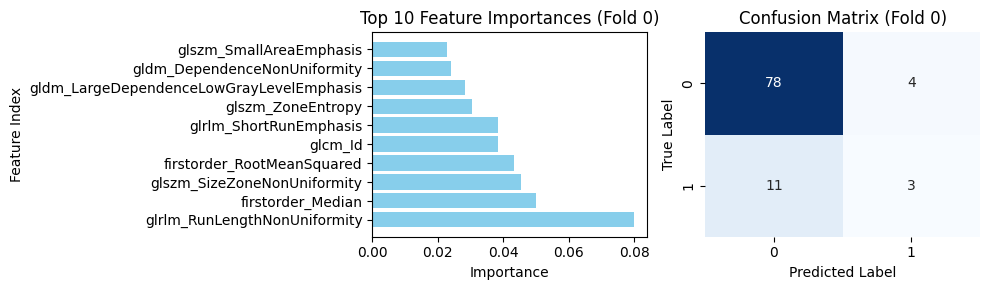


Fold 1:
Original train class distribution: Counter({0: 260, 1: 48})
Original test class distribution: Counter({0: 56, 1: 18})
Best parameters for fold 1: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.7}

Fold 1 results:
Accuracy: 0.8243
F1-macro: 0.6872
F1-micro: 0.8243
F1-weighted: 0.7935
Precision: 0.8571
Recall: 0.3333
ROC AUC: 0.7956
True Positives: 6, False Negatives: 12, False Positives: 1, True Negatives: 55


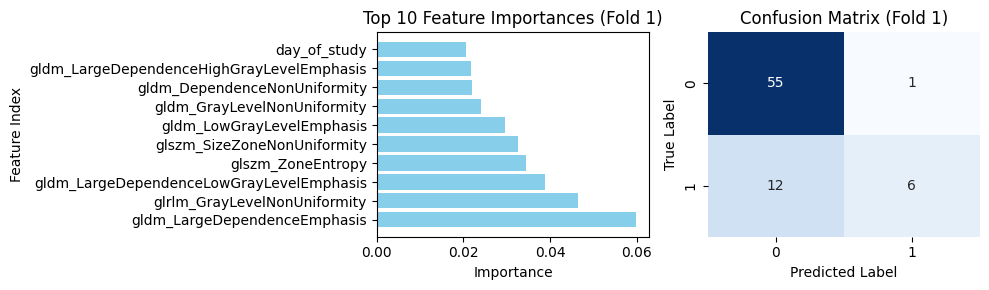


Fold 2:
Original train class distribution: Counter({0: 282, 1: 48})
Original test class distribution: Counter({0: 34, 1: 18})
Best parameters for fold 2: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.8}

Fold 2 results:
Accuracy: 0.7115
F1-macro: 0.5813
F1-micro: 0.7115
F1-weighted: 0.6532
Precision: 0.8000
Recall: 0.2222
ROC AUC: 0.7778
True Positives: 4, False Negatives: 14, False Positives: 1, True Negatives: 33


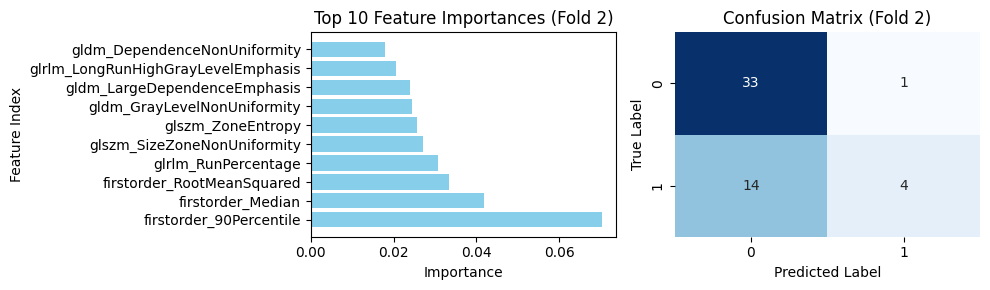


Fold 3:
Original train class distribution: Counter({0: 250, 1: 57})
Original test class distribution: Counter({0: 66, 1: 9})
Best parameters for fold 3: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 1.0}

Fold 3 results:
Accuracy: 0.8133
F1-macro: 0.6528
F1-micro: 0.8133
F1-weighted: 0.8322
Precision: 0.3333
Recall: 0.5556
ROC AUC: 0.8064
True Positives: 5, False Negatives: 4, False Positives: 10, True Negatives: 56


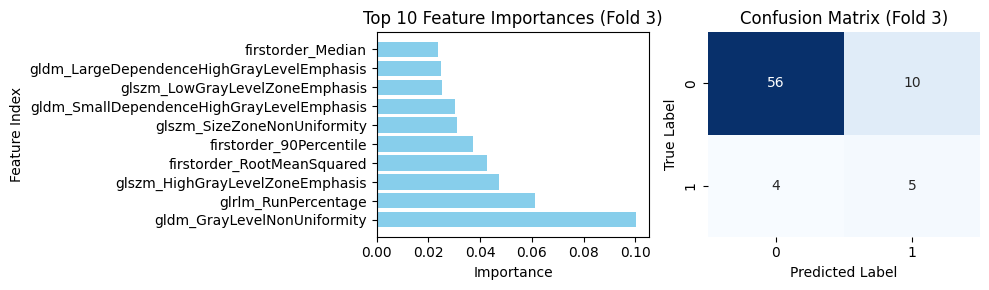


All Folds Completed.

--------------------------------------------------

Summary of Results:



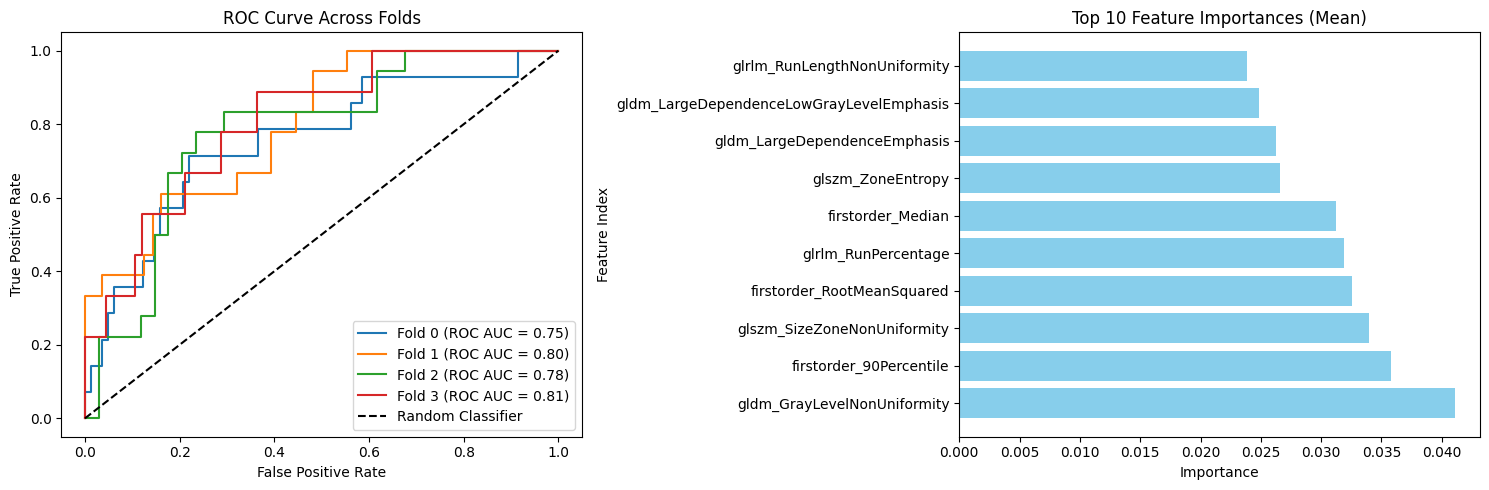


Summary Across Folds:
Mean accuracy: 0.7982
Mean F1-macro: 0.6301
Mean F1-micro: 0.7982
Mean F1-weighted: 0.7750
Mean precision: 0.6048
Mean recall: 0.3313
Mean ROC AUC: 0.7835


In [34]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler

# Track results for each fold
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_pr_aucs, fold_f1_micros, fold_f1_weighted, feature_importances = [], [], [], [], [], [], [], [], []
class_metrics = {'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Store ROC and PR curve points for all folds
roc_curves = []
pr_curves = []

split_0_data = next(iter(m_data.values()))
# print(split_0_data['X_train'].columns)

feature_names = split_0_data['X_train'].columns  # This will be a pandas.Index
feature_names = feature_names.str.replace('original_', '', regex=False)

for fold, split_data in m_data.items():
    print(f"\nFold {fold}:")
    print(f"Original train class distribution: {Counter(split_data['y_train'])}")
    print(f"Original test class distribution: {Counter(split_data['y_test'])}")

    model = Pipeline([
        ('scaler', StandardScaler()), 
        ('smote', SMOTE(random_state=SEED)),
        ('xgbclassifier', xgb.XGBClassifier(random_state=SEED)),
    ])

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(split_data['X_train'], split_data['y_train'])

    best_model = grid_search.best_estimator_
    print(f"Best parameters for fold {fold}: {grid_search.best_params_}")

    # Extract feature importances from XGBoost
    xgb_model = best_model.named_steps['xgbclassifier']
    importances = xgb_model.feature_importances_

    # Evaluate on the test set
    preds = best_model.predict(split_data['X_test'])
    preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class
    
    # Calculate metrics
    accuracy = accuracy_score(split_data['y_test'], preds)
    f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    f1_micro = f1_score(split_data['y_test'], preds, average='micro')
    f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
    precision = precision_score(split_data['y_test'], preds)
    recall = recall_score(split_data['y_test'], preds)

    fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)

    # precision_c, recall_c, _ = precision_recall_curve(split_data['y_test'], preds_proba, pos_label=1)
    # pr_auc = average_precision_score(split_data['y_test'], preds_proba)
    
    roc_curves.append((fpr, tpr))
    # pr_curves.append((precision_c, recall_c))

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()

    # Print fold results
    print(f"\nFold {fold} results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"F1-micro: {f1_micro:.4f}")
    print(f"F1-weighted: {f1_weighted:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    # print(f"PR AUC: {pr_auc:.4f}")
    print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
    
    # Plot top k features for this fold
    top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
    top_importances = importances[top_indices]
    # print(top_importances)
    # print(top_indices)
    # print(feature_names[top_indices])

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
    plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
    plt.ylabel("Feature Index")
    plt.xlabel("Importance")
    plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
    # Plot confusion matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(split_data['y_test'], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix (Fold {fold})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # Track results
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_f1_micros.append(f1_micro)
    fold_f1_weighted.append(f1_weighted)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_roc_aucs.append(roc_auc)
    feature_importances.append(importances)
    # fold_pr_aucs.append(pr_auc)

    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

print(f"\nAll Folds Completed.")
print("\n--------------------------------------------------")
print("\nSummary of Results:\n")

# print(feature_importances)

# Plotting ROC and Precision-Recall curves side by side
plt.figure(figsize=(15, 5))

# ROC Curve Plot
plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
for i, (fpr, tpr) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.title("ROC Curve Across Folds")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Calculate mean importances across folds
mean_importances = np.mean(feature_importances, axis=0)
# print(mean_importances)
# Get indices of the top k features by mean
top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
top_importances_mean = mean_importances[top_indices_mean]
# print(top_indices_mean)
# print(top_importances_mean)
# print(feature_names[top_indices_mean])

plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
plt.ylabel("Feature Index")
plt.xlabel("Importance")
plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

# Precision-Recall Curve Plot
# plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
# for i, (precision, recall) in enumerate(pr_curves):
#     plt.plot(recall, precision, label=f'Fold {i} (PR AUC = {fold_pr_aucs[i]:.2f})')
# plt.title("Precision-Recall Curve Across Folds")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.legend(loc="lower right")

# Display the plots side by side
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

# Display summary statistics across folds
print(f"\nSummary Across Folds:")
print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
print(f"Mean precision: {np.mean(fold_precisions):.4f}")
print(f"Mean recall: {np.mean(fold_recalls):.4f}")
print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")
# print(f"Mean PR AUC: {np.mean(fold_pr_aucs):.4f}")

In [ ]:
# Individually timer series split by m_id
# Define the outer cross-validation settings
n_splits = 6
test_size = 0.2

# Initialize result storage
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls = [], [], [], []
class_metrics = {'precision_class_0': [], 'precision_class_1': [], 'recall_class_0': [], 'recall_class_1': [],
                 'f1_class_0': [], 'f1_class_1': [], 'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Nested cross-validation split function
def split_data_nested_cv_ts(df, n_splits=n_splits, test_size=test_size):
    print(f"Performing nested cross-validation with {n_splits} inner splits and test size of {test_size}")
    splits = {}
    # il = 0
    for _, group in df.groupby('m_id'):
        # print(f"Processing mouse {m_id}")
        # if il == 2:
        #     break
        group = group.sort_values(by='day_of_study').reset_index(drop=True)
        # print(f"Group: {group}")

        if len(group) < n_splits + 1:
            # print(f"Adding mouse {group['m_id'].iloc[0]} to train set due to insufficient data")
            split_idx = 0
            if split_idx not in splits:
                # print("Don't know why this is happening")
                X_train, y_train = group.drop(columns=['m_id', 'group_name']), group['group_name']
                # print('heeeu', [(list(range(len(X_train))), list())])
                splits[split_idx] = {
                    'X_train': X_train,
                    'y_train': y_train,
                    # 'train_cv_split': [(list(range(len(X_train))), list())],
                    'X_test': None,
                    'y_test': None
                }
            else:
                if splits[split_idx]['X_train'] is None and splits[split_idx]['y_train'] is None:
                    # print('Empty')
                    # print("Don't know why this is happening")
                    X_train, y_train = group.drop(columns=['m_id', 'group_name']), group['group_name']
                    splits[split_idx]['X_train'] = X_train
                    splits[split_idx]['y_train'] = y_train
                    # splits[split_idx]['train_cv_split'] = [(list(range(len(X_train))), list())]
                else:
                    # print('Not empty')
                    X_train, y_train = group.drop(columns=['m_id', 'group_name']), group['group_name']
                    splits[split_idx]['X_train'] = pd.concat([splits[split_idx]['X_train'], X_train], axis=0, ignore_index=True)
                    splits[split_idx]['y_train'] = pd.concat([splits[split_idx]['y_train'], y_train], axis=0, ignore_index=True)
                    # Print new train_cv_split
                    # print([(list(range(len(X_train))), list())])
                    # print('new train_cv_split', [i + len(splits[split_idx]['X_train']) for i in list(range(len(X_train)))])
                    splits[split_idx]['train_cv_split'][0][0].extend([i + len(splits[split_idx]['X_train']) for i in list(range(len(X_train)))])
            continue

        tscv = TimeSeriesSplit(n_splits=n_splits + 1).split(group)  # Inner CV for tuning
        next(tscv)  # Skip the first split

        for split_idx, (train_cv_indices, test_indices) in enumerate(tscv):
            X_train, y_train = group.iloc[train_cv_indices].drop(columns=['m_id', 'group_name']), group.iloc[train_cv_indices]['group_name']
            X_test, y_test = group.iloc[test_indices].drop(columns=['m_id', 'group_name']), group.iloc[test_indices]['group_name']

            # print(f"train_cv_split: {train_cv_split}")
            # Mostrar los valores de '10Percentile' para cada conjunto
            # print("Training:", X_train['10Percentile'].iloc[0], "--", X_train['10Percentile'].iloc[-test_len-1],
            #     ", CV:", X_train['10Percentile'].iloc[-test_len], "--", X_train['10Percentile'].iloc[-1],
            #     ", Test:", X_test['10Percentile'].iloc[0], "--", X_test['10Percentile'].iloc[-1])

            if split_idx not in splits:
                splits[split_idx] = {
                    'X_train': X_train,
                    'y_train': y_train,
                    'X_test': X_test,
                    'y_test': y_test
                }
            else:
                # #print(splits[split_idx]['train_cv_split'])
                # # To add new train and cv indices we have to take into account the previous instance indices
                # splits[split_idx]['train_cv_split'][0][0].extend([i + len(splits[split_idx]['X_train']) for i in train_cv_split[0][0]])
                # splits[split_idx]['train_cv_split'][0][1].extend([i + len(splits[split_idx]['X_train']) for i in train_cv_split[0][1]])
                # To add new train and cv indices we have to take into account the previous instance indices
                #splits[split_idx]['train_cv_split'].append()

                splits[split_idx]['X_train'] = pd.concat([splits[split_idx]['X_train'], X_train], axis=0, ignore_index=True)
                splits[split_idx]['y_train'] = pd.concat([splits[split_idx]['y_train'], y_train], axis=0, ignore_index=True)
                splits[split_idx]['X_test'] = pd.concat([splits[split_idx]['X_test'], X_test], axis=0, ignore_index=True)
                splits[split_idx]['y_test'] = pd.concat([splits[split_idx]['y_test'], y_test], axis=0, ignore_index=True)

        #  il += 1

    return splits

m_data = split_data_nested_cv_ts(df)

Performing nested cross-validation with 6 inner splits and test size of 0.2



Fold 0:
Original train class distribution: Counter({0: 106, 1: 24})
Original test class distribution: Counter({0: 35, 1: 7})
Best parameters for fold 0: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 1.0}

Fold 0 results:
Accuracy: 0.6667
F1-macro: 0.5051
F1-micro: 0.6667
F1-weighted: 0.6936
Precision: 0.1818
Recall: 0.2857
ROC AUC: 0.5102
True Positives: 2, False Negatives: 5, False Positives: 9, True Negatives: 26


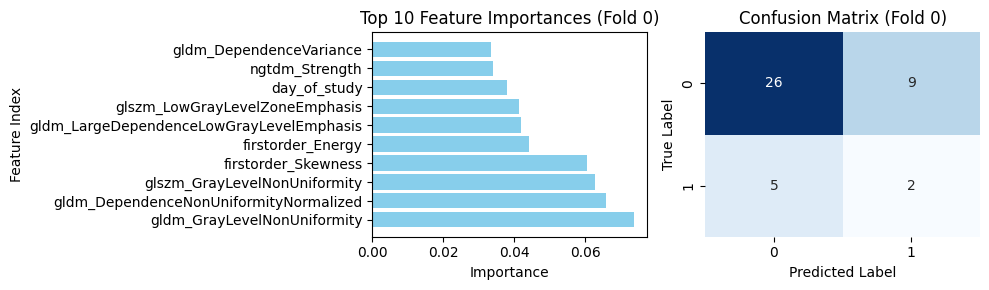


Fold 1:
Original train class distribution: Counter({0: 137, 1: 31})
Original test class distribution: Counter({0: 35, 1: 7})
Best parameters for fold 1: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 1.0}

Fold 1 results:
Accuracy: 0.7857
F1-macro: 0.6681
F1-micro: 0.7857
F1-weighted: 0.7998
Precision: 0.4000
Recall: 0.5714
ROC AUC: 0.7510
True Positives: 4, False Negatives: 3, False Positives: 6, True Negatives: 29


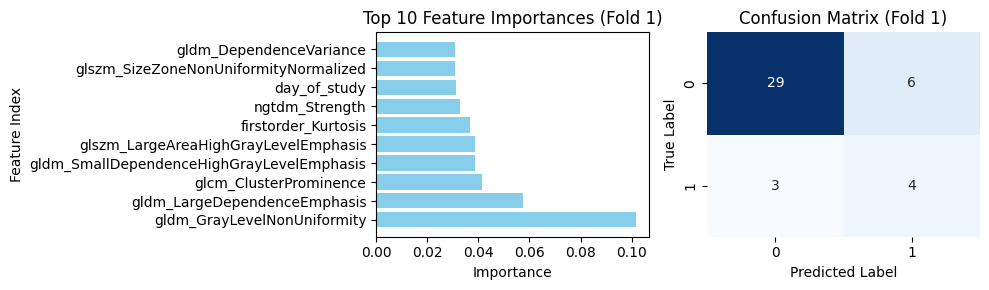


Fold 2:
Original train class distribution: Counter({0: 172, 1: 38})
Original test class distribution: Counter({0: 35, 1: 7})
Best parameters for fold 2: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 1.0}

Fold 2 results:
Accuracy: 0.8095
F1-macro: 0.6111
F1-micro: 0.8095
F1-weighted: 0.7963
Precision: 0.4000
Recall: 0.2857
ROC AUC: 0.6653
True Positives: 2, False Negatives: 5, False Positives: 3, True Negatives: 32


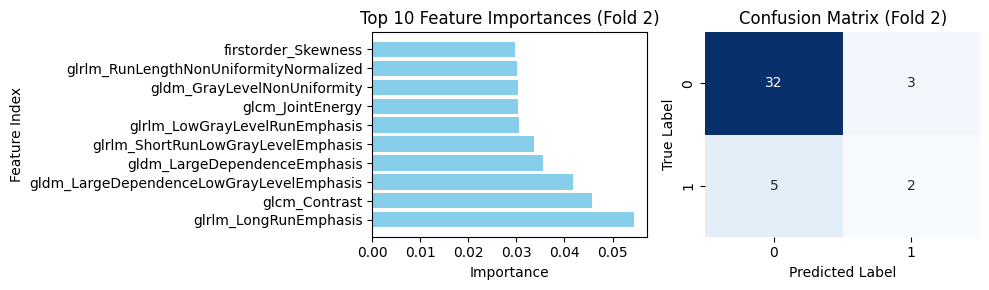


Fold 3:
Original train class distribution: Counter({0: 207, 1: 45})
Original test class distribution: Counter({0: 35, 1: 7})
Best parameters for fold 3: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.7}

Fold 3 results:
Accuracy: 0.8571
F1-macro: 0.6595
F1-micro: 0.8571
F1-weighted: 0.8324
Precision: 0.6667
Recall: 0.2857
ROC AUC: 0.8286
True Positives: 2, False Negatives: 5, False Positives: 1, True Negatives: 34


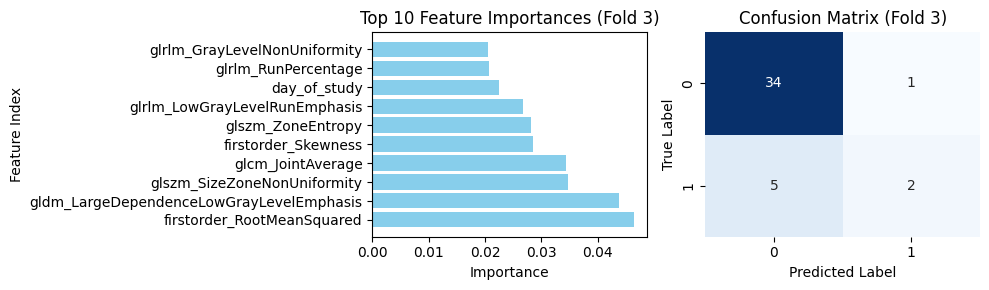


Fold 4:
Original train class distribution: Counter({0: 242, 1: 52})
Original test class distribution: Counter({0: 35, 1: 7})
Best parameters for fold 4: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 1.0}

Fold 4 results:
Accuracy: 0.9048
F1-macro: 0.7730
F1-micro: 0.9048
F1-weighted: 0.8883
Precision: 1.0000
Recall: 0.4286
ROC AUC: 0.9020
True Positives: 3, False Negatives: 4, False Positives: 0, True Negatives: 35


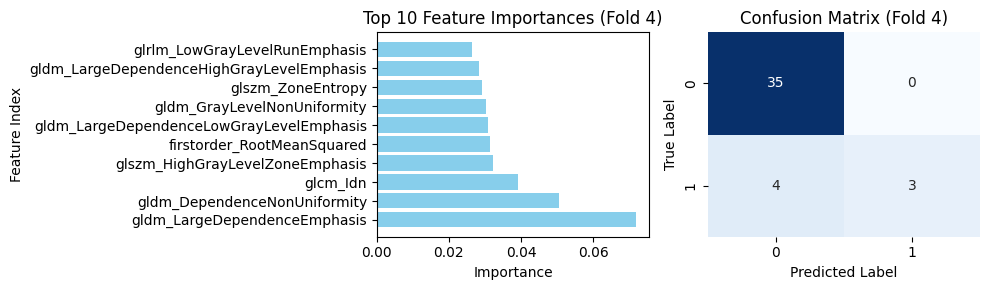


Fold 5:
Original train class distribution: Counter({0: 277, 1: 59})
Original test class distribution: Counter({0: 35, 1: 7})
Best parameters for fold 5: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.7}

Fold 5 results:
Accuracy: 0.9048
F1-macro: 0.7730
F1-micro: 0.9048
F1-weighted: 0.8883
Precision: 1.0000
Recall: 0.4286
ROC AUC: 0.7837
True Positives: 3, False Negatives: 4, False Positives: 0, True Negatives: 35


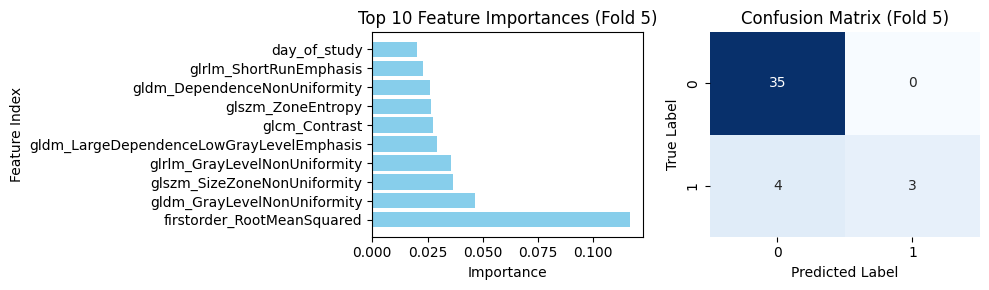


All Folds Completed.

--------------------------------------------------

Summary of Results:



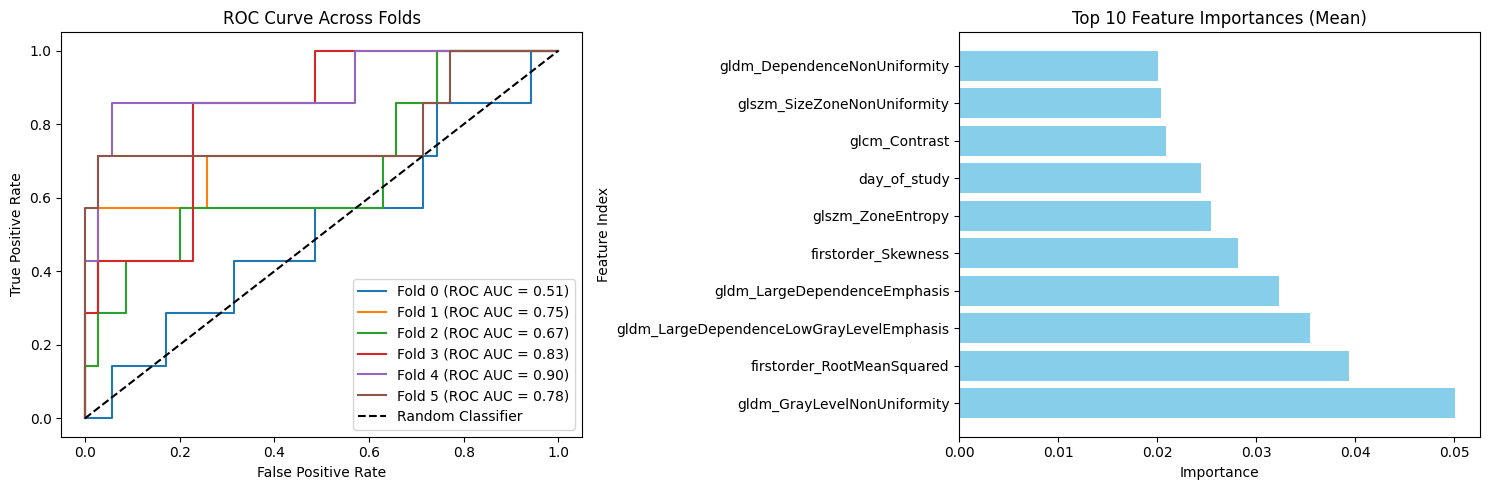


Summary Across Folds:
Mean accuracy: 0.8214
Mean F1-macro: 0.6649
Mean F1-micro: 0.8214
Mean F1-weighted: 0.8165
Mean precision: 0.6081
Mean recall: 0.3810
Mean ROC AUC: 0.7401


In [36]:
# Track results for each fold
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_pr_aucs, fold_f1_micros, fold_f1_weighted, feature_importances = [], [], [], [], [], [], [], [], []
class_metrics = {'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Store ROC and PR curve points for all folds
roc_curves = []
pr_curves = []

split_0_data = next(iter(m_data.values()))
# print(split_0_data['X_train'].columns)

feature_names = split_0_data['X_train'].columns  # This will be a pandas.Index
feature_names = feature_names.str.replace('original_', '', regex=False)

for fold, split_data in m_data.items():
    print(f"\nFold {fold}:")
    print(f"Original train class distribution: {Counter(split_data['y_train'])}")
    print(f"Original test class distribution: {Counter(split_data['y_test'])}")

    model = Pipeline([
        ('scaler', StandardScaler()), 
        ('smote', SMOTE(random_state=SEED)),
        ('xgbclassifier', xgb.XGBClassifier(random_state=SEED)),
    ])

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(split_data['X_train'], split_data['y_train'])

    best_model = grid_search.best_estimator_
    print(f"Best parameters for fold {fold}: {grid_search.best_params_}")

    # Extract feature importances from XGBoost
    xgb_model = best_model.named_steps['xgbclassifier']
    importances = xgb_model.feature_importances_

    # Evaluate on the test set
    preds = best_model.predict(split_data['X_test'])
    preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class
    
    # Calculate metrics
    accuracy = accuracy_score(split_data['y_test'], preds)
    f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    f1_micro = f1_score(split_data['y_test'], preds, average='micro')
    f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
    precision = precision_score(split_data['y_test'], preds)
    recall = recall_score(split_data['y_test'], preds)

    fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)

    # precision_c, recall_c, _ = precision_recall_curve(split_data['y_test'], preds_proba, pos_label=1)
    # pr_auc = average_precision_score(split_data['y_test'], preds_proba)
    
    roc_curves.append((fpr, tpr))
    # pr_curves.append((precision_c, recall_c))

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()

    # Print fold results
    print(f"\nFold {fold} results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"F1-micro: {f1_micro:.4f}")
    print(f"F1-weighted: {f1_weighted:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    # print(f"PR AUC: {pr_auc:.4f}")
    print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
    
    # Plot top k features for this fold
    top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
    top_importances = importances[top_indices]
    # print(top_importances)
    # print(top_indices)
    # print(feature_names[top_indices])

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
    plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
    plt.ylabel("Feature Index")
    plt.xlabel("Importance")
    plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
    # Plot confusion matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(split_data['y_test'], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix (Fold {fold})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # Track results
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_f1_micros.append(f1_micro)
    fold_f1_weighted.append(f1_weighted)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_roc_aucs.append(roc_auc)
    feature_importances.append(importances)
    # fold_pr_aucs.append(pr_auc)

    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

print(f"\nAll Folds Completed.")
print("\n--------------------------------------------------")
print("\nSummary of Results:\n")

# print(feature_importances)

# Plotting ROC and Precision-Recall curves side by side
plt.figure(figsize=(15, 5))

# ROC Curve Plot
plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
for i, (fpr, tpr) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.title("ROC Curve Across Folds")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Calculate mean importances across folds
mean_importances = np.mean(feature_importances, axis=0)
# print(mean_importances)
# Get indices of the top k features by mean
top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
top_importances_mean = mean_importances[top_indices_mean]
# print(top_indices_mean)
# print(top_importances_mean)
# print(feature_names[top_indices_mean])

plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
plt.ylabel("Feature Index")
plt.xlabel("Importance")
plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

# Precision-Recall Curve Plot
# plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
# for i, (precision, recall) in enumerate(pr_curves):
#     plt.plot(recall, precision, label=f'Fold {i} (PR AUC = {fold_pr_aucs[i]:.2f})')
# plt.title("Precision-Recall Curve Across Folds")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.legend(loc="lower right")

# Display the plots side by side
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

# Display summary statistics across folds
print(f"\nSummary Across Folds:")
print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
print(f"Mean precision: {np.mean(fold_precisions):.4f}")
print(f"Mean recall: {np.mean(fold_recalls):.4f}")
print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")
# print(f"Mean PR AUC: {np.mean(fold_pr_aucs):.4f}")

In [57]:
from itertools import combinations
import random

def grouped_combinations_split_with_sampling(df, n_splits=4, sample_size=5, seed=SEED):
    """
    Generate a random sample of combinations of 'm_id' groups for train-test splits.

    Args:
        df (pd.DataFrame): DataFrame containing all instances, including 'm_id' and 'group_name'.
        n_splits (int): Number of splits (used to calculate test size proportion).
        sample_size (int): Number of random combinations to sample.
        seed (int): Random seed for reproducibility.

    Returns:
        splits (list): List of dictionaries, each representing one train-test split combination.
    """
    random.seed(seed)  # Ensure reproducibility
    splits = {}
    
    # Get all unique mouse IDs
    unique_mice = df['m_id'].unique()

    # Compute the size of the test group based on n_splits
    test_size = len(unique_mice) // n_splits

    # Generate all possible combinations of 'm_id' for the test set
    test_combinations = list(combinations(unique_mice, test_size))
    print(f"Total possible combinations: {len(test_combinations)}")

    # Randomly sample a subset of the combinations
    sampled_combinations = random.sample(test_combinations, k=sample_size)

    # Create splits for the sampled combinations
    for i, test_group in enumerate(sampled_combinations):
        # Test mice are those in the current combination
        test_mice = set(test_group)
        
        # Train mice are the remaining mice
        train_mice = set(unique_mice) - test_mice

        # Filter the DataFrame for train and test data
        train_data = df[df['m_id'].isin(train_mice)].reset_index(drop=True)
        test_data = df[df['m_id'].isin(test_mice)].reset_index(drop=True)

        # Prepare X (features) and y (labels) for train and test sets
        X_train = train_data.drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_train = train_data['group_name'].reset_index(drop=True)

        X_test = test_data.drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_test = test_data['group_name'].reset_index(drop=True)

        # Append this combination to the splits
        splits[i] = {
            'X_train': X_train,
            'y_train': y_train,
            'X_test': X_test,
            'y_test': y_test
        }

    return splits

# Example usage
sample_size = 5  # Number of splits you want to sample
m_data = grouped_combinations_split_with_sampling(df, n_splits=4, sample_size=sample_size, seed=SEED)
print(f"Generated {len(m_data)} sampled combinations.")



Total possible combinations: 3060
Generated 5 sampled combinations.



Fold 0:
Original train class distribution: Counter({0: 301, 1: 29})
Original test class distribution: Counter({1: 37, 0: 15})
Best parameters for fold 0: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 0 results:
Accuracy: 0.4808
F1-macro: 0.4759
F1-micro: 0.4808
F1-weighted: 0.4546
Precision: 1.0000
Recall: 0.2703
ROC AUC: 0.7423
True Positives: 10, False Negatives: 27, False Positives: 0, True Negatives: 15


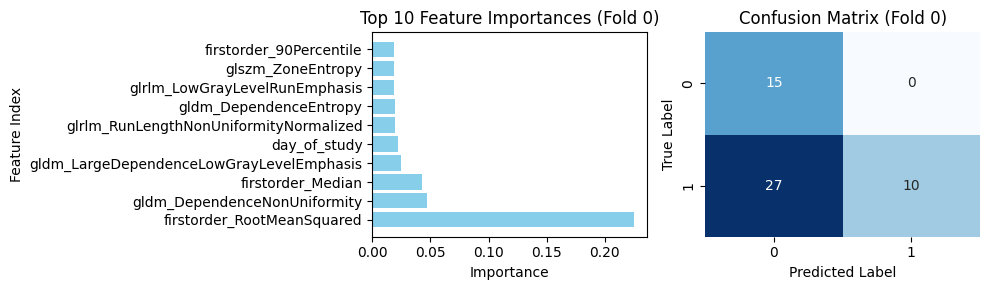


Fold 1:
Original train class distribution: Counter({0: 212, 1: 66})
Original test class distribution: Counter({0: 104})
Best parameters for fold 1: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.7}

Fold 1 results:
Accuracy: 0.7019
F1-macro: 0.4124
F1-micro: 0.7019
F1-weighted: 0.8249
Precision: 0.0000
Recall: 1.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 31, True Negatives: 73


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


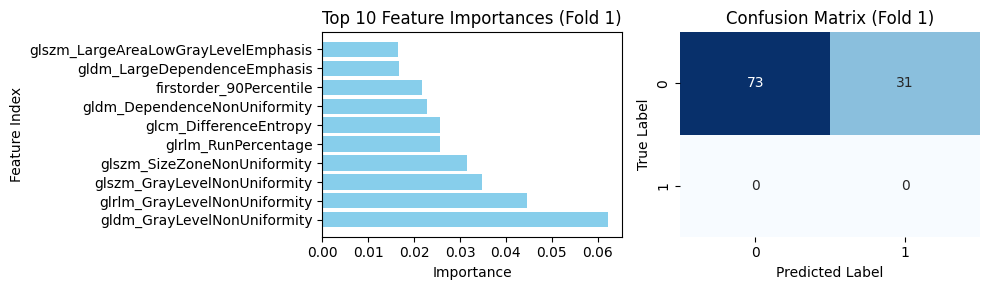


Fold 2:
Original train class distribution: Counter({0: 248, 1: 49})
Original test class distribution: Counter({0: 68, 1: 17})
Best parameters for fold 2: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 1.0}

Fold 2 results:
Accuracy: 0.8118
F1-macro: 0.5823
F1-micro: 0.8118
F1-weighted: 0.7681
Precision: 0.6000
Recall: 0.1765
ROC AUC: 0.6981
True Positives: 3, False Negatives: 14, False Positives: 2, True Negatives: 66


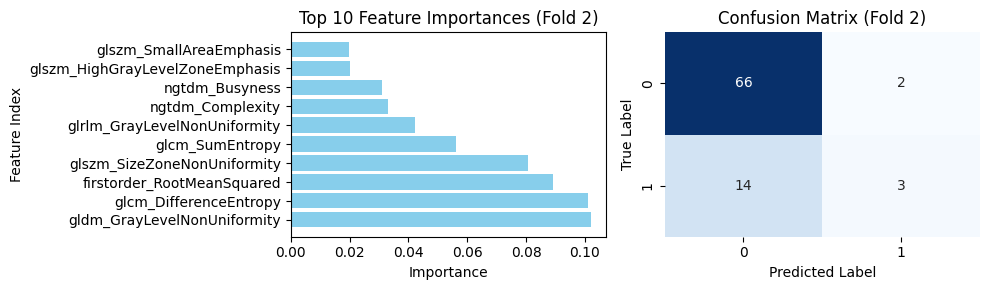


Fold 3:
Original train class distribution: Counter({0: 174, 1: 49})
Original test class distribution: Counter({0: 142, 1: 17})
Best parameters for fold 3: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 1.0}

Fold 3 results:
Accuracy: 0.4717
F1-macro: 0.3576
F1-micro: 0.4717
F1-weighted: 0.5704
Precision: 0.0533
Recall: 0.2353
ROC AUC: 0.3540
True Positives: 4, False Negatives: 13, False Positives: 71, True Negatives: 71


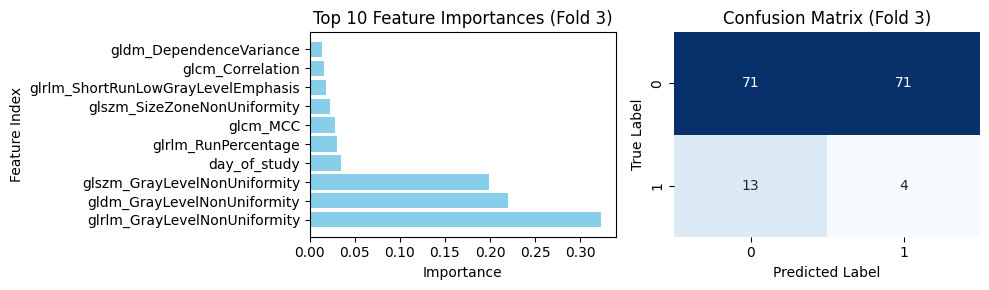


Fold 4:
Original train class distribution: Counter({0: 253, 1: 33})
Original test class distribution: Counter({0: 63, 1: 33})
Best parameters for fold 4: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.8}

Fold 4 results:
Accuracy: 0.7292
F1-macro: 0.6389
F1-micro: 0.7292
F1-weighted: 0.6953
Precision: 0.7333
Recall: 0.3333
ROC AUC: 0.7638
True Positives: 11, False Negatives: 22, False Positives: 4, True Negatives: 59


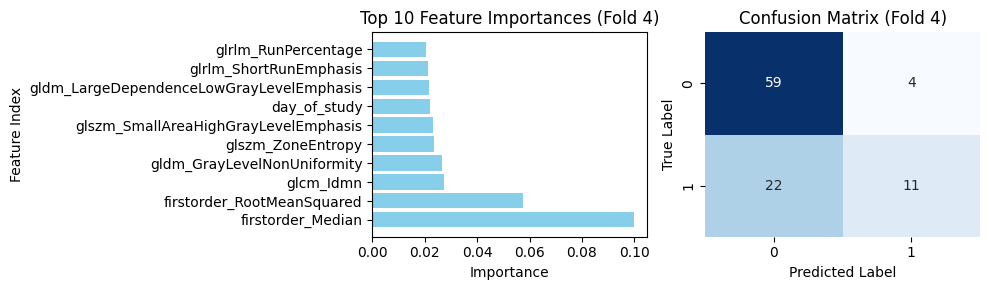


All Folds Completed.

--------------------------------------------------

Summary of Results:



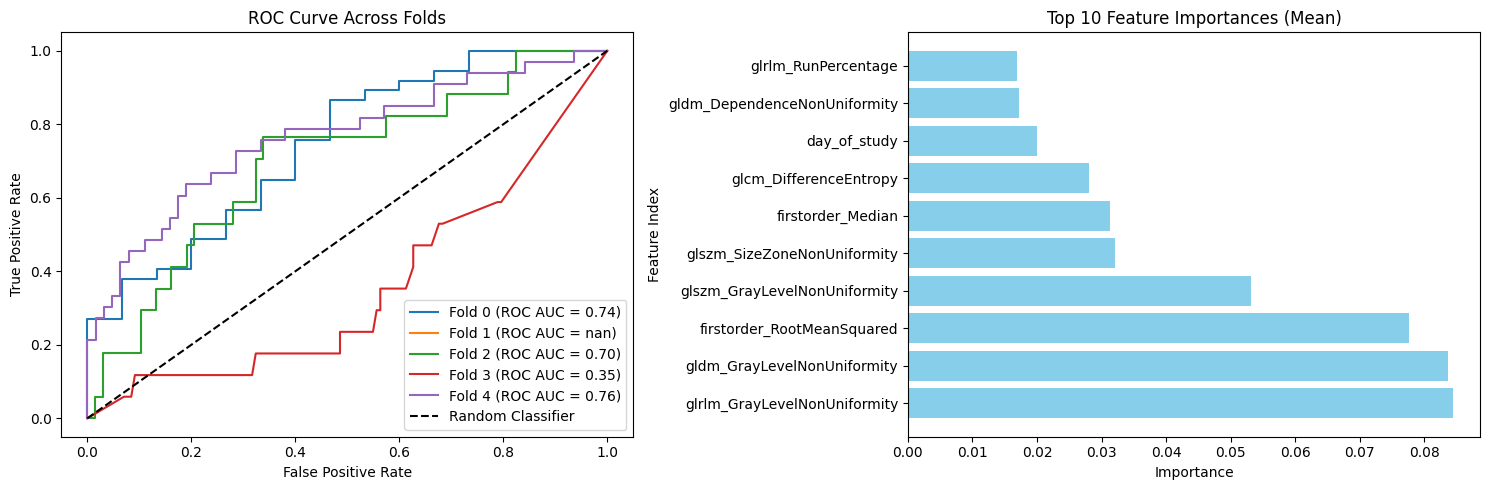


Summary Across Folds:
Mean accuracy: 0.6391
Mean F1-macro: 0.4934
Mean F1-micro: 0.6391
Mean F1-weighted: 0.6627
Mean precision: 0.4773
Mean recall: 0.4031
Mean ROC AUC: nan


In [ ]:
# Track results for each fold
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_pr_aucs, fold_f1_micros, fold_f1_weighted, feature_importances = [], [], [], [], [], [], [], [], []
class_metrics = {'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Store ROC and PR curve points for all folds
roc_curves = []
pr_curves = []

split_0_data = next(iter(m_data.values()))
# print(split_0_data['X_train'].columns)

feature_names = split_0_data['X_train'].columns  # This will be a pandas.Index
feature_names = feature_names.str.replace('original_', '', regex=False)

for fold, split_data in m_data.items():
    print(f"\nFold {fold}:")
    print(f"Original train class distribution: {Counter(split_data['y_train'])}")
    print(f"Original test class distribution: {Counter(split_data['y_test'])}")

    model = Pipeline([
        ('scaler', StandardScaler()), 
        ('smote', SMOTE(random_state=SEED)),
        ('xgbclassifier', xgb.XGBClassifier(random_state=SEED)),
    ])

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(split_data['X_train'], split_data['y_train'])

    best_model = grid_search.best_estimator_
    print(f"Best parameters for fold {fold}: {grid_search.best_params_}")

    # Extract feature importances from XGBoost
    xgb_model = best_model.named_steps['xgbclassifier']
    importances = xgb_model.feature_importances_

    # Evaluate on the test set
    preds = best_model.predict(split_data['X_test'])
    preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class
    
    # Calculate metrics
    accuracy = accuracy_score(split_data['y_test'], preds)
    f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    f1_micro = f1_score(split_data['y_test'], preds, average='micro')
    f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
    precision = precision_score(split_data['y_test'], preds, zero_division=0)
    recall = recall_score(split_data['y_test'], preds, zero_division=0) 

    fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)

    # precision_c, recall_c, _ = precision_recall_curve(split_data['y_test'], preds_proba, pos_label=1)
    # pr_auc = average_precision_score(split_data['y_test'], preds_proba)
    
    roc_curves.append((fpr, tpr))
    # pr_curves.append((precision_c, recall_c))

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()

    # Print fold results
    print(f"\nFold {fold} results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"F1-micro: {f1_micro:.4f}")
    print(f"F1-weighted: {f1_weighted:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    # print(f"PR AUC: {pr_auc:.4f}")
    print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
    
    # Plot top k features for this fold
    top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
    top_importances = importances[top_indices]
    # print(top_importances)
    # print(top_indices)
    # print(feature_names[top_indices])

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
    plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
    plt.ylabel("Feature Index")
    plt.xlabel("Importance")
    plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
    # Plot confusion matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(split_data['y_test'], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix (Fold {fold})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # Track results
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_f1_micros.append(f1_micro)
    fold_f1_weighted.append(f1_weighted)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_roc_aucs.append(roc_auc)
    feature_importances.append(importances)
    # fold_pr_aucs.append(pr_auc)

    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

print(f"\nAll Folds Completed.")
print("\n--------------------------------------------------")
print("\nSummary of Results:\n")

# print(feature_importances)

# Plotting ROC and Precision-Recall curves side by side
plt.figure(figsize=(15, 5))

# ROC Curve Plot
plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
for i, (fpr, tpr) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.title("ROC Curve Across Folds")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Calculate mean importances across folds
mean_importances = np.mean(feature_importances, axis=0)
# print(mean_importances)
# Get indices of the top k features by mean
top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
top_importances_mean = mean_importances[top_indices_mean]
# print(top_indices_mean)
# print(top_importances_mean)
# print(feature_names[top_indices_mean])

plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
plt.ylabel("Feature Index")
plt.xlabel("Importance")
plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

# Precision-Recall Curve Plot
# plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
# for i, (precision, recall) in enumerate(pr_curves):
#     plt.plot(recall, precision, label=f'Fold {i} (PR AUC = {fold_pr_aucs[i]:.2f})')
# plt.title("Precision-Recall Curve Across Folds")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.legend(loc="lower right")

# Display the plots side by side
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

# Display summary statistics across folds
print(f"\nSummary Across Folds:")
print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
print(f"Mean precision: {np.mean(fold_precisions):.4f}")
print(f"Mean recall: {np.mean(fold_recalls):.4f}")
print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")
# print(f"Mean PR AUC: {np.mean(fold_pr_aucs):.4f}")

In [ ]:
from itertools import combinations
import random

def grouped_combinations_split_with_sampling(df, n_splits=4, sample_size=50, seed=42):
    """
    Generate a random sample of combinations of 'm_id' groups for train-test splits.

    Args:
        df (pd.DataFrame): DataFrame containing all instances, including 'm_id' and 'group_name'.
        n_splits (int): Number of splits (used to calculate test size proportion).
        sample_size (int): Number of random combinations to sample.
        seed (int): Random seed for reproducibility.

    Returns:
        splits (list): List of dictionaries, each representing one train-test split combination.
    """
    random.seed(seed)  # Ensure reproducibility
    splits = {}
    
    # Get all unique mouse IDs
    unique_mice = df['m_id'].unique()

    # Compute the size of the test group based on n_splits
    test_size = len(unique_mice) // n_splits

    # Generate all possible combinations of 'm_id' for the test set
    test_combinations = list(combinations(unique_mice, test_size))
    print(f"Total possible combinations: {len(test_combinations)}")

    # Randomly sample a subset of the combinations
    sampled_combinations = random.sample(test_combinations, k=sample_size)

    # Create splits for the sampled combinations
    for i, test_group in enumerate(sampled_combinations):
        # Test mice are those in the current combination
        test_mice = set(test_group)
        
        # Train mice are the remaining mice
        train_mice = set(unique_mice) - test_mice

        # Filter the DataFrame for train and test data
        train_data = df[df['m_id'].isin(train_mice)].reset_index(drop=True)
        test_data = df[df['m_id'].isin(test_mice)].reset_index(drop=True)

        # Prepare X (features) and y (labels) for train and test sets
        X_train = train_data.drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_train = train_data['group_name'].reset_index(drop=True)

        X_test = test_data.drop(columns=['group_name', 'm_id']).reset_index(drop=True)
        y_test = test_data['group_name'].reset_index(drop=True)

        # Append this combination to the splits
        splits[i] = {
            'X_train': X_train,
            'y_train': y_train,
            'X_test': X_test,
            'y_test': y_test
        }

    return splits

# Example usage
sample_size = 50  # Number of splits you want to sample
m_data = grouped_combinations_split_with_sampling(df, n_splits=4, sample_size=sample_size, seed=SEED)
print(f"Generated {len(m_data)} sampled combinations.")



Total possible combinations: 3060
Generated 50 sampled combinations.



Fold 0:
Original train class distribution: Counter({0: 301, 1: 29})
Original test class distribution: Counter({1: 37, 0: 15})
Best parameters for fold 0: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 0 results:
Accuracy: 0.4808
F1-macro: 0.4759
F1-micro: 0.4808
F1-weighted: 0.4546
Precision: 1.0000
Recall: 0.2703
ROC AUC: 0.7423
True Positives: 10, False Negatives: 27, False Positives: 0, True Negatives: 15


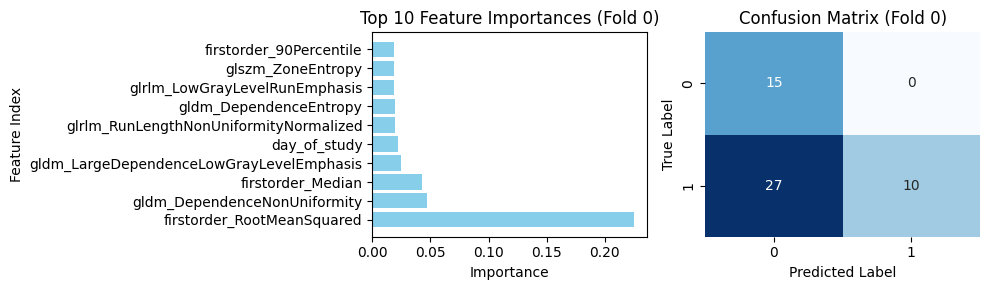


Fold 1:
Original train class distribution: Counter({0: 212, 1: 66})
Original test class distribution: Counter({0: 104})
Best parameters for fold 1: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.7}

Fold 1 results:
Accuracy: 0.7019
F1-macro: 0.4124
F1-micro: 0.7019
F1-weighted: 0.8249
Precision: 0.0000
Recall: 0.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 31, True Negatives: 73


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


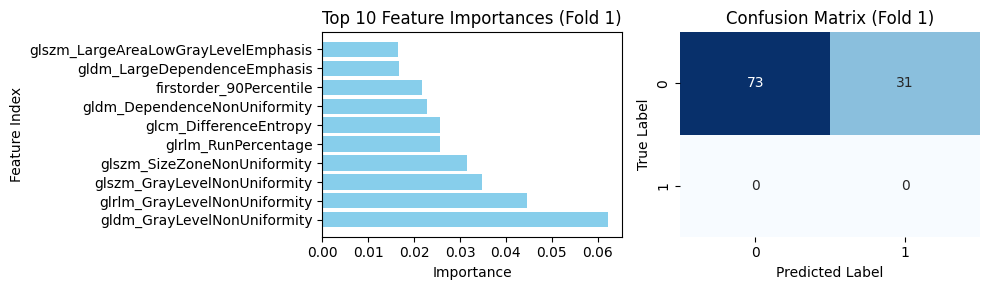


Fold 2:
Original train class distribution: Counter({0: 248, 1: 49})
Original test class distribution: Counter({0: 68, 1: 17})
Best parameters for fold 2: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 1.0}

Fold 2 results:
Accuracy: 0.8118
F1-macro: 0.5823
F1-micro: 0.8118
F1-weighted: 0.7681
Precision: 0.6000
Recall: 0.1765
ROC AUC: 0.6981
True Positives: 3, False Negatives: 14, False Positives: 2, True Negatives: 66


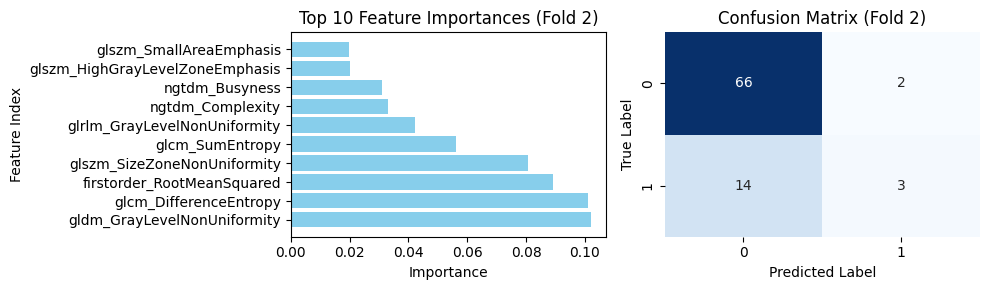


Fold 3:
Original train class distribution: Counter({0: 174, 1: 49})
Original test class distribution: Counter({0: 142, 1: 17})
Best parameters for fold 3: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 1.0}

Fold 3 results:
Accuracy: 0.4717
F1-macro: 0.3576
F1-micro: 0.4717
F1-weighted: 0.5704
Precision: 0.0533
Recall: 0.2353
ROC AUC: 0.3540
True Positives: 4, False Negatives: 13, False Positives: 71, True Negatives: 71


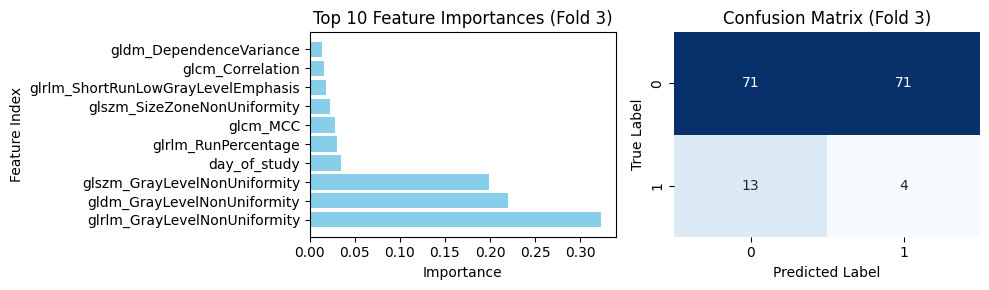


Fold 4:
Original train class distribution: Counter({0: 253, 1: 33})
Original test class distribution: Counter({0: 63, 1: 33})
Best parameters for fold 4: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.8}

Fold 4 results:
Accuracy: 0.7292
F1-macro: 0.6389
F1-micro: 0.7292
F1-weighted: 0.6953
Precision: 0.7333
Recall: 0.3333
ROC AUC: 0.7638
True Positives: 11, False Negatives: 22, False Positives: 4, True Negatives: 59


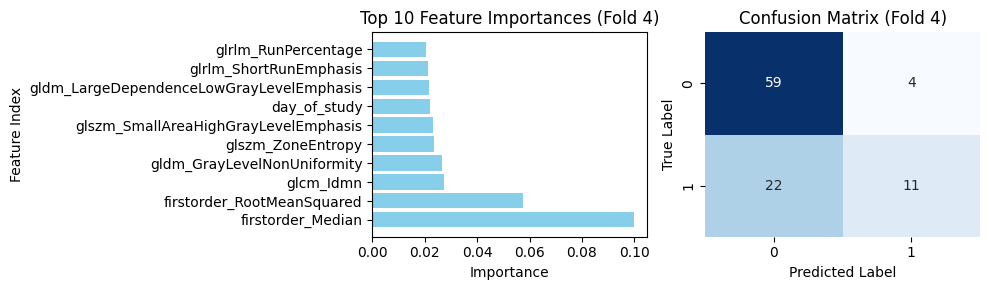


Fold 5:
Original train class distribution: Counter({0: 244, 1: 49})
Original test class distribution: Counter({0: 72, 1: 17})
Best parameters for fold 5: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.7}

Fold 5 results:
Accuracy: 0.8090
F1-macro: 0.5411
F1-micro: 0.8090
F1-weighted: 0.7578
Precision: 0.5000
Recall: 0.1176
ROC AUC: 0.6855
True Positives: 2, False Negatives: 15, False Positives: 2, True Negatives: 70


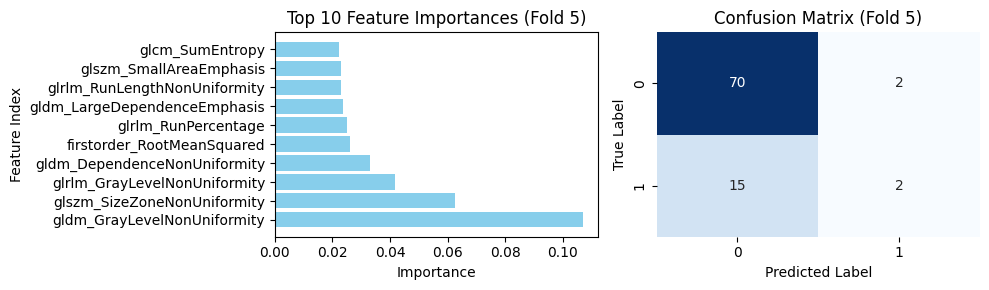


Fold 6:
Original train class distribution: Counter({0: 255, 1: 45})
Original test class distribution: Counter({0: 61, 1: 21})
Best parameters for fold 6: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.8}

Fold 6 results:
Accuracy: 0.7561
F1-macro: 0.6290
F1-micro: 0.7561
F1-weighted: 0.7349
Precision: 0.5385
Recall: 0.3333
ROC AUC: 0.6612
True Positives: 7, False Negatives: 14, False Positives: 6, True Negatives: 55


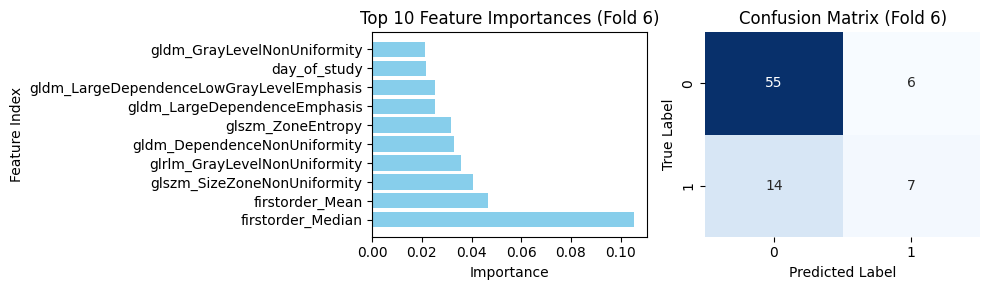


Fold 7:
Original train class distribution: Counter({0: 264, 1: 37})
Original test class distribution: Counter({0: 52, 1: 29})
Best parameters for fold 7: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 1.0}

Fold 7 results:
Accuracy: 0.7160
F1-macro: 0.6635
F1-micro: 0.7160
F1-weighted: 0.7013
Precision: 0.6500
Recall: 0.4483
ROC AUC: 0.6916
True Positives: 13, False Negatives: 16, False Positives: 7, True Negatives: 45


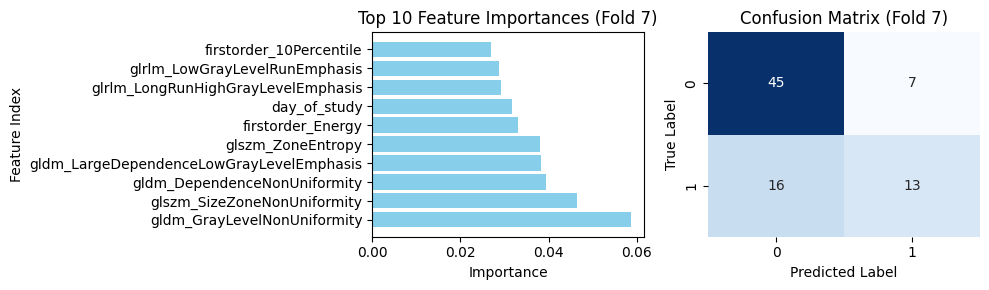


Fold 8:
Original train class distribution: Counter({0: 170, 1: 58})
Original test class distribution: Counter({0: 146, 1: 8})
Best parameters for fold 8: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.8}

Fold 8 results:
Accuracy: 0.6234
F1-macro: 0.4527
F1-micro: 0.6234
F1-weighted: 0.7266
Precision: 0.0833
Recall: 0.6250
ROC AUC: 0.8193
True Positives: 5, False Negatives: 3, False Positives: 55, True Negatives: 91


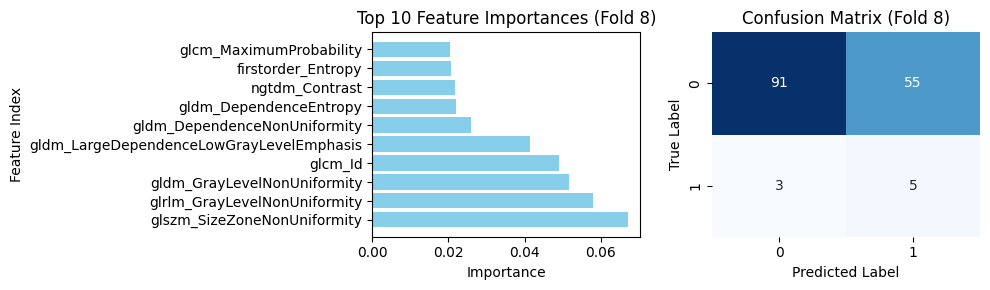


Fold 9:
Original train class distribution: Counter({0: 242, 1: 45})
Original test class distribution: Counter({0: 74, 1: 21})
Best parameters for fold 9: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 1.0}

Fold 9 results:
Accuracy: 0.7158
F1-macro: 0.5942
F1-micro: 0.7158
F1-weighted: 0.7181
Precision: 0.3636
Recall: 0.3810
ROC AUC: 0.6416
True Positives: 8, False Negatives: 13, False Positives: 14, True Negatives: 60


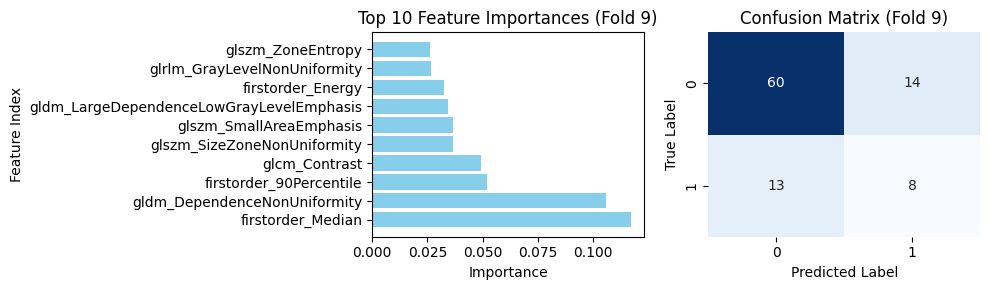


Fold 10:
Original train class distribution: Counter({0: 257, 1: 46})
Original test class distribution: Counter({0: 59, 1: 20})
Best parameters for fold 10: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.7}

Fold 10 results:
Accuracy: 0.6835
F1-macro: 0.5589
F1-micro: 0.6835
F1-weighted: 0.6746
Precision: 0.3529
Recall: 0.3000
ROC AUC: 0.5483
True Positives: 6, False Negatives: 14, False Positives: 11, True Negatives: 48


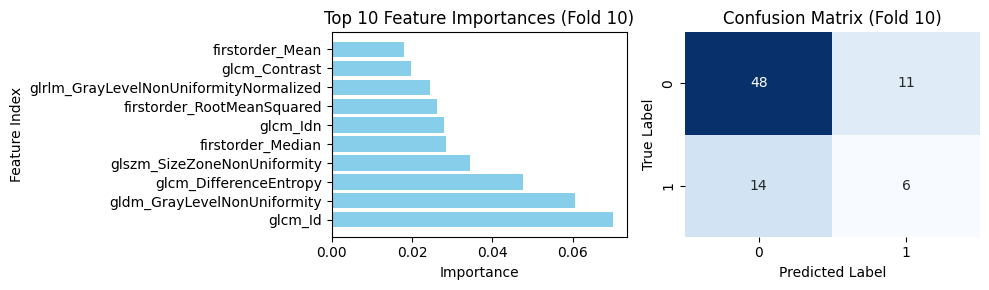


Fold 11:
Original train class distribution: Counter({0: 230, 1: 41})
Original test class distribution: Counter({0: 86, 1: 25})
Best parameters for fold 11: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.7}

Fold 11 results:
Accuracy: 0.7658
F1-macro: 0.5253
F1-micro: 0.7658
F1-weighted: 0.7110
Precision: 0.4286
Recall: 0.1200
ROC AUC: 0.6735
True Positives: 3, False Negatives: 22, False Positives: 4, True Negatives: 82


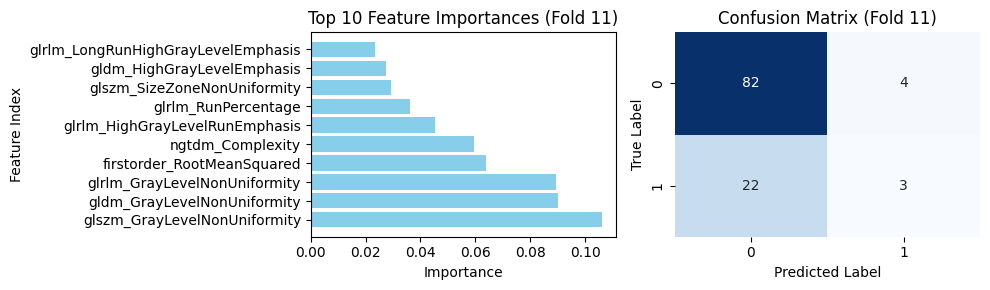


Fold 12:
Original train class distribution: Counter({0: 314, 1: 20})
Original test class distribution: Counter({1: 46, 0: 2})
Best parameters for fold 12: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 12 results:
Accuracy: 0.2292
F1-macro: 0.2124
F1-micro: 0.2292
F1-weighted: 0.3177
Precision: 1.0000
Recall: 0.1957
ROC AUC: 0.9565
True Positives: 9, False Negatives: 37, False Positives: 0, True Negatives: 2


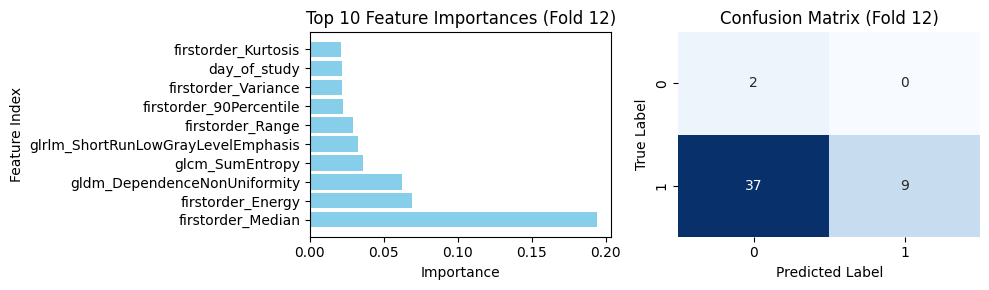


Fold 13:
Original train class distribution: Counter({0: 258, 1: 45})
Original test class distribution: Counter({0: 58, 1: 21})
Best parameters for fold 13: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 13 results:
Accuracy: 0.7342
F1-macro: 0.6146
F1-micro: 0.7342
F1-weighted: 0.7152
Precision: 0.5000
Recall: 0.3333
ROC AUC: 0.6626
True Positives: 7, False Negatives: 14, False Positives: 7, True Negatives: 51


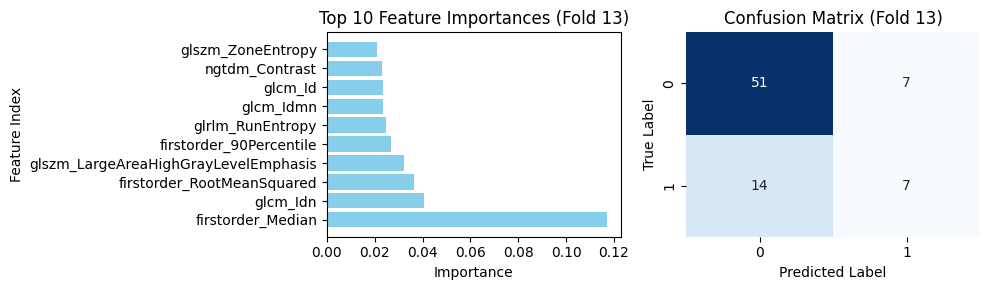


Fold 14:
Original train class distribution: Counter({0: 295, 1: 50})
Original test class distribution: Counter({0: 21, 1: 16})
Best parameters for fold 14: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.7}

Fold 14 results:
Accuracy: 0.6757
F1-macro: 0.6300
F1-micro: 0.6757
F1-weighted: 0.6476
Precision: 0.7500
Recall: 0.3750
ROC AUC: 0.7411
True Positives: 6, False Negatives: 10, False Positives: 2, True Negatives: 19


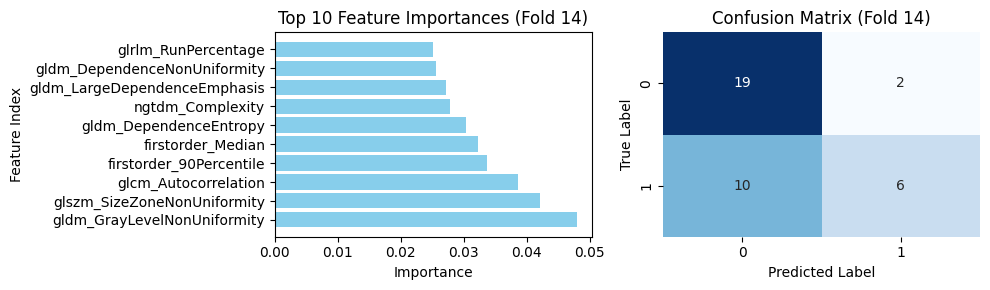


Fold 15:
Original train class distribution: Counter({0: 312, 1: 33})
Original test class distribution: Counter({1: 33, 0: 4})
Best parameters for fold 15: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.7}

Fold 15 results:
Accuracy: 0.5405
F1-macro: 0.4865
F1-micro: 0.5405
F1-weighted: 0.6171
Precision: 1.0000
Recall: 0.4848
ROC AUC: 0.8409
True Positives: 16, False Negatives: 17, False Positives: 0, True Negatives: 4


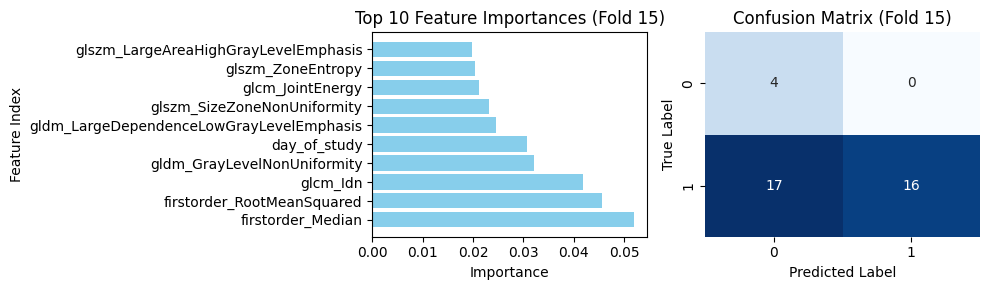


Fold 16:
Original train class distribution: Counter({0: 243, 1: 66})
Original test class distribution: Counter({0: 73})
Best parameters for fold 16: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 1.0}

Fold 16 results:
Accuracy: 0.7808
F1-macro: 0.4385
F1-micro: 0.7808
F1-weighted: 0.8769
Precision: 0.0000
Recall: 0.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 16, True Negatives: 57


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


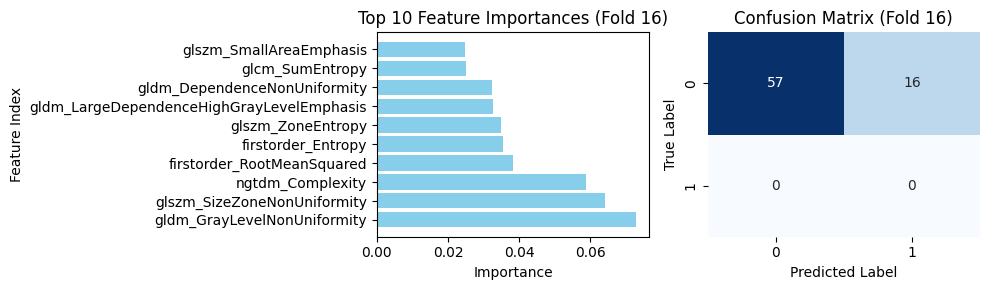


Fold 17:
Original train class distribution: Counter({0: 271, 1: 66})
Original test class distribution: Counter({0: 45})
Best parameters for fold 17: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 1.0}

Fold 17 results:
Accuracy: 0.8444
F1-macro: 0.4578
F1-micro: 0.8444
F1-weighted: 0.9157
Precision: 0.0000
Recall: 0.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 7, True Negatives: 38


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


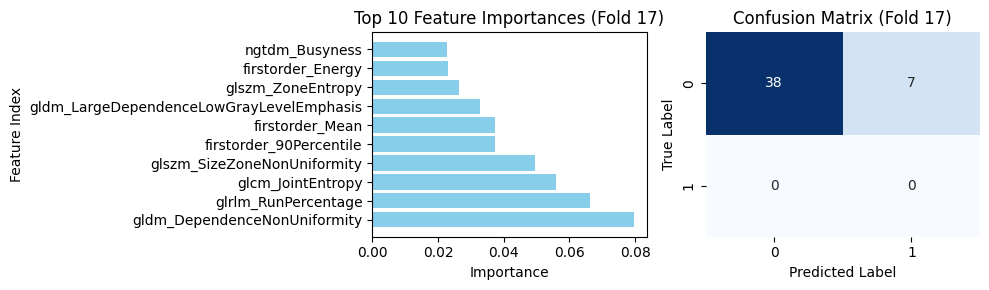


Fold 18:
Original train class distribution: Counter({0: 262, 1: 58})
Original test class distribution: Counter({0: 54, 1: 8})
Best parameters for fold 18: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 18 results:
Accuracy: 0.7419
F1-macro: 0.4801
F1-micro: 0.7419
F1-weighted: 0.7538
Precision: 0.1000
Recall: 0.1250
ROC AUC: 0.6644
True Positives: 1, False Negatives: 7, False Positives: 9, True Negatives: 45


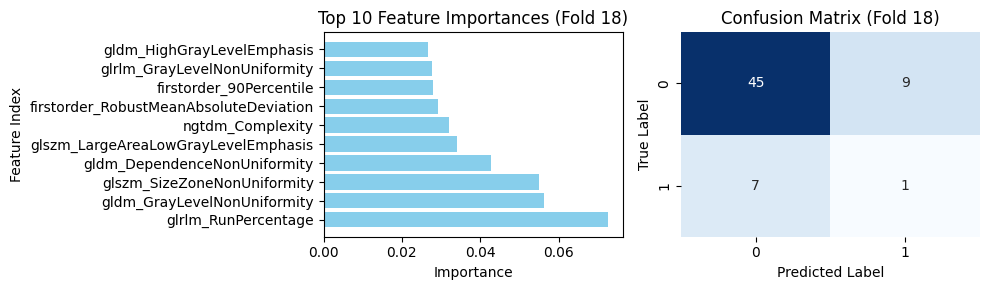


Fold 19:
Original train class distribution: Counter({0: 240, 1: 66})
Original test class distribution: Counter({0: 76})
Best parameters for fold 19: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 1.0}

Fold 19 results:
Accuracy: 0.5658
F1-macro: 0.3613
F1-micro: 0.5658
F1-weighted: 0.7227
Precision: 0.0000
Recall: 0.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 33, True Negatives: 43


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


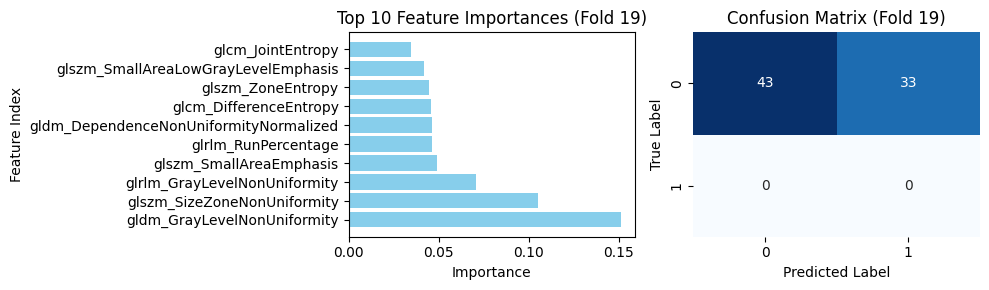


Fold 20:
Original train class distribution: Counter({0: 212, 1: 66})
Original test class distribution: Counter({0: 104})
Best parameters for fold 20: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.8}

Fold 20 results:
Accuracy: 0.8942
F1-macro: 0.4721
F1-micro: 0.8942
F1-weighted: 0.9442
Precision: 0.0000
Recall: 0.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 11, True Negatives: 93


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


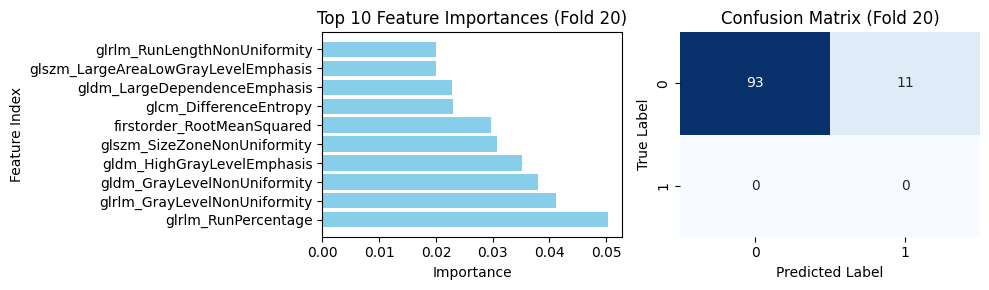


Fold 21:
Original train class distribution: Counter({0: 247, 1: 66})
Original test class distribution: Counter({0: 69})
Best parameters for fold 21: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 1.0}

Fold 21 results:
Accuracy: 0.8261
F1-macro: 0.4524
F1-micro: 0.8261
F1-weighted: 0.9048
Precision: 0.0000
Recall: 0.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 12, True Negatives: 57


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


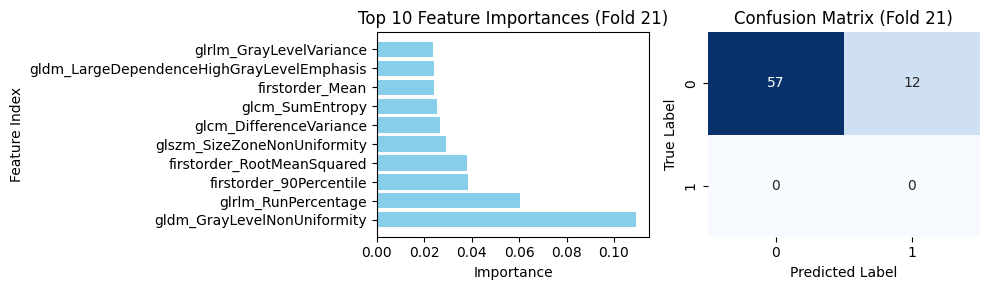


Fold 22:
Original train class distribution: Counter({0: 264, 1: 28})
Original test class distribution: Counter({0: 52, 1: 38})
Best parameters for fold 22: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.8}

Fold 22 results:
Accuracy: 0.5667
F1-macro: 0.4385
F1-micro: 0.5667
F1-weighted: 0.4802
Precision: 0.4444
Recall: 0.1053
ROC AUC: 0.6210
True Positives: 4, False Negatives: 34, False Positives: 5, True Negatives: 47


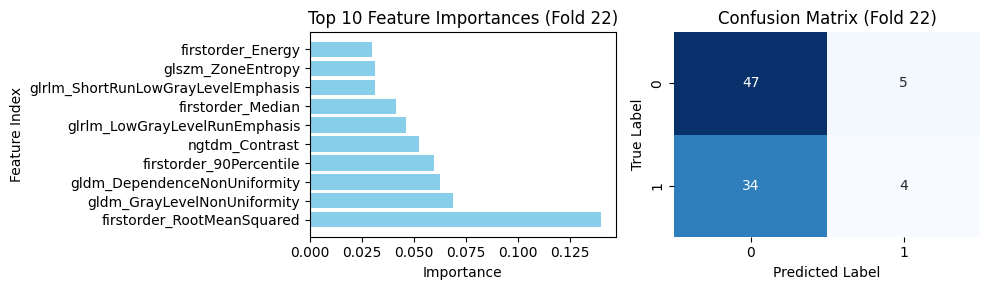


Fold 23:
Original train class distribution: Counter({0: 244, 1: 58})
Original test class distribution: Counter({0: 72, 1: 8})
Best parameters for fold 23: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 1.0}

Fold 23 results:
Accuracy: 0.8625
F1-macro: 0.5954
F1-micro: 0.8625
F1-weighted: 0.8584
Precision: 0.2857
Recall: 0.2500
ROC AUC: 0.7049
True Positives: 2, False Negatives: 6, False Positives: 5, True Negatives: 67


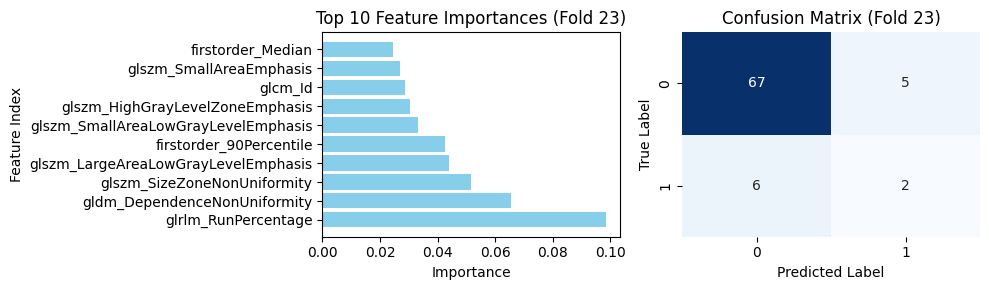


Fold 24:
Original train class distribution: Counter({0: 267, 1: 50})
Original test class distribution: Counter({0: 49, 1: 16})
Best parameters for fold 24: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 1.0}

Fold 24 results:
Accuracy: 0.7692
F1-macro: 0.6671
F1-micro: 0.7692
F1-weighted: 0.7607
Precision: 0.5385
Recall: 0.4375
ROC AUC: 0.8342
True Positives: 7, False Negatives: 9, False Positives: 6, True Negatives: 43


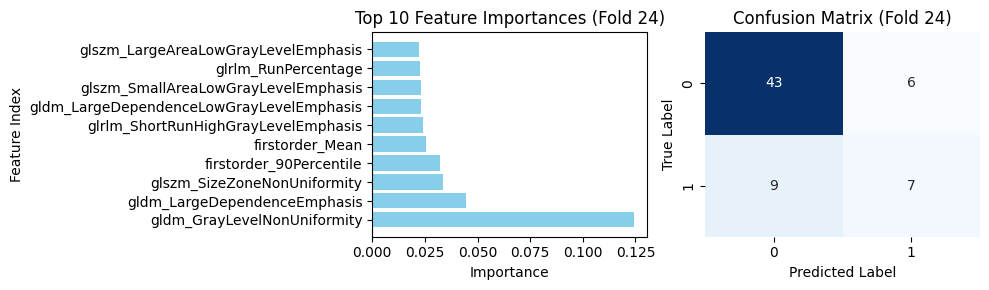


Fold 25:
Original train class distribution: Counter({0: 283, 1: 49})
Original test class distribution: Counter({0: 33, 1: 17})
Best parameters for fold 25: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 1.0}

Fold 25 results:
Accuracy: 0.7000
F1-macro: 0.5127
F1-micro: 0.7000
F1-weighted: 0.6094
Precision: 1.0000
Recall: 0.1176
ROC AUC: 0.5811
True Positives: 2, False Negatives: 15, False Positives: 0, True Negatives: 33


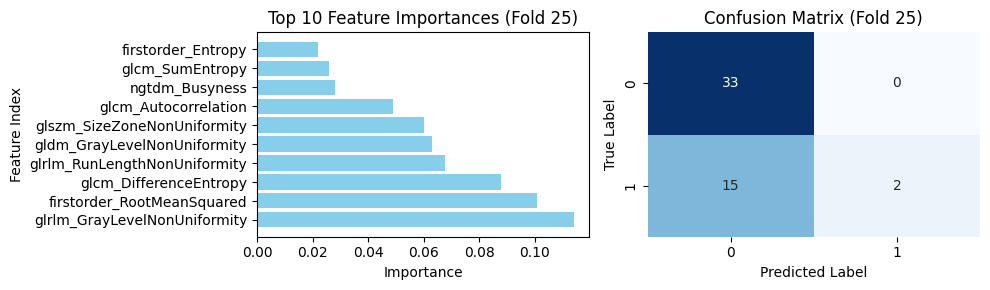


Fold 26:
Original train class distribution: Counter({0: 183, 1: 45})
Original test class distribution: Counter({0: 133, 1: 21})
Best parameters for fold 26: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.7}

Fold 26 results:
Accuracy: 0.7922
F1-macro: 0.6180
F1-micro: 0.7922
F1-weighted: 0.8056
Precision: 0.3103
Recall: 0.4286
ROC AUC: 0.7587
True Positives: 9, False Negatives: 12, False Positives: 20, True Negatives: 113


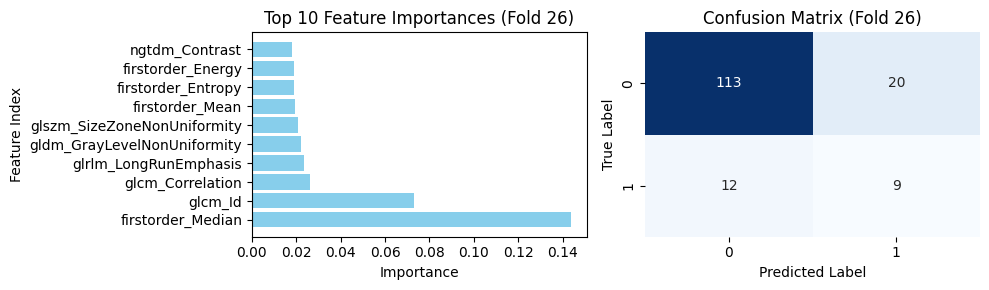


Fold 27:
Original train class distribution: Counter({0: 258, 1: 46})
Original test class distribution: Counter({0: 58, 1: 20})
Best parameters for fold 27: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 1.0}

Fold 27 results:
Accuracy: 0.7564
F1-macro: 0.6752
F1-micro: 0.7564
F1-weighted: 0.7543
Precision: 0.5263
Recall: 0.5000
ROC AUC: 0.7233
True Positives: 10, False Negatives: 10, False Positives: 9, True Negatives: 49


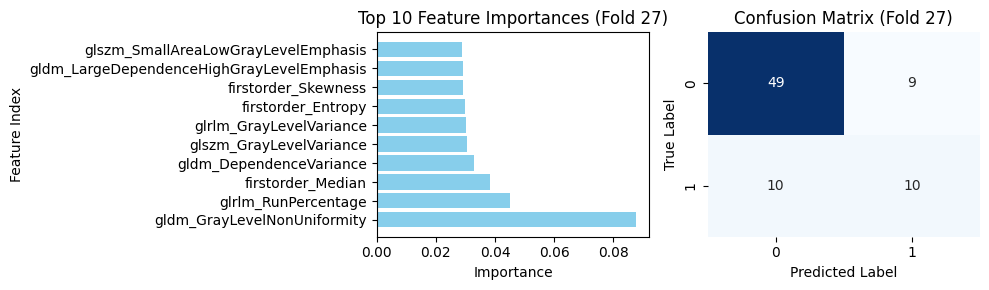


Fold 28:
Original train class distribution: Counter({0: 230, 1: 33})
Original test class distribution: Counter({0: 86, 1: 33})
Best parameters for fold 28: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.7}

Fold 28 results:
Accuracy: 0.7311
F1-macro: 0.6706
F1-micro: 0.7311
F1-weighted: 0.7335
Precision: 0.5143
Recall: 0.5455
ROC AUC: 0.7530
True Positives: 18, False Negatives: 15, False Positives: 17, True Negatives: 69


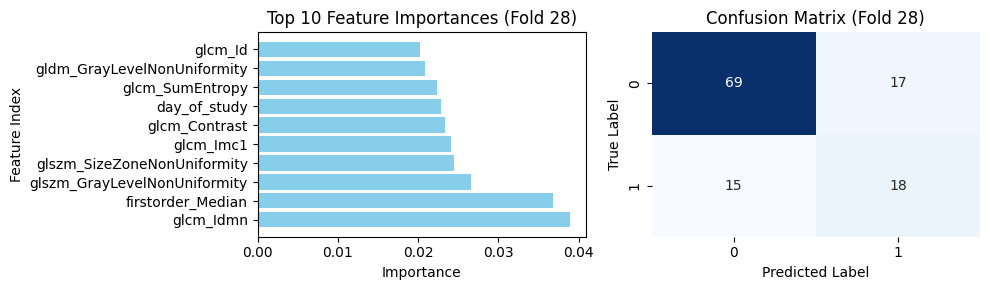


Fold 29:
Original train class distribution: Counter({0: 271, 1: 33})
Original test class distribution: Counter({0: 45, 1: 33})
Best parameters for fold 29: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.7}

Fold 29 results:
Accuracy: 0.7179
F1-macro: 0.7056
F1-micro: 0.7179
F1-weighted: 0.7149
Precision: 0.6897
Recall: 0.6061
ROC AUC: 0.7360
True Positives: 20, False Negatives: 13, False Positives: 9, True Negatives: 36


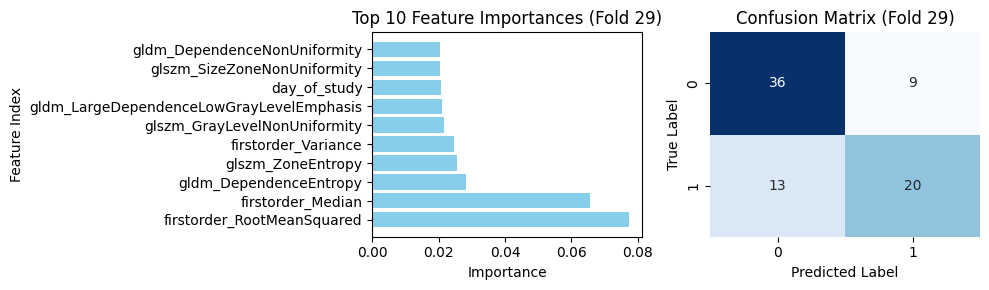


Fold 30:
Original train class distribution: Counter({0: 300, 1: 45})
Original test class distribution: Counter({1: 21, 0: 16})
Best parameters for fold 30: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.8}

Fold 30 results:
Accuracy: 0.5405
F1-macro: 0.5180
F1-micro: 0.5405
F1-weighted: 0.5039
Precision: 0.7500
Recall: 0.2857
ROC AUC: 0.6220
True Positives: 6, False Negatives: 15, False Positives: 2, True Negatives: 14


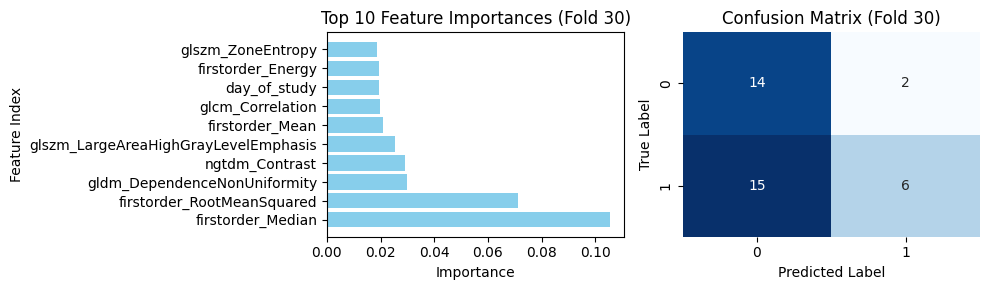


Fold 31:
Original train class distribution: Counter({0: 286, 1: 49})
Original test class distribution: Counter({0: 30, 1: 17})
Best parameters for fold 31: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.7}

Fold 31 results:
Accuracy: 0.6383
F1-macro: 0.4788
F1-micro: 0.6383
F1-weighted: 0.5585
Precision: 0.5000
Recall: 0.1176
ROC AUC: 0.5137
True Positives: 2, False Negatives: 15, False Positives: 2, True Negatives: 28


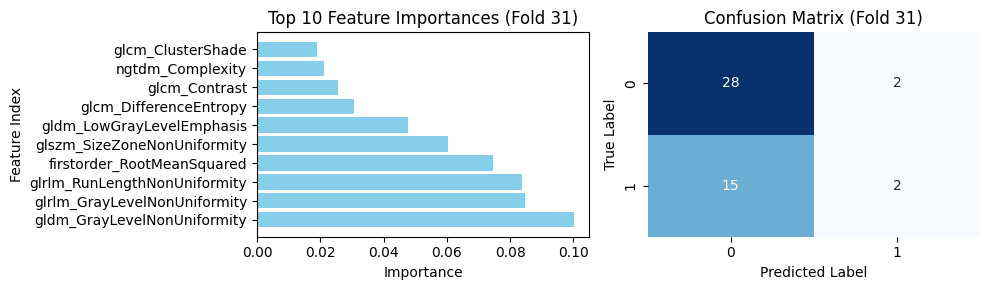


Fold 32:
Original train class distribution: Counter({0: 287, 1: 45})
Original test class distribution: Counter({0: 29, 1: 21})
Best parameters for fold 32: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 32 results:
Accuracy: 0.6400
F1-macro: 0.5536
F1-micro: 0.6400
F1-weighted: 0.5850
Precision: 0.7143
Recall: 0.2381
ROC AUC: 0.5944
True Positives: 5, False Negatives: 16, False Positives: 2, True Negatives: 27


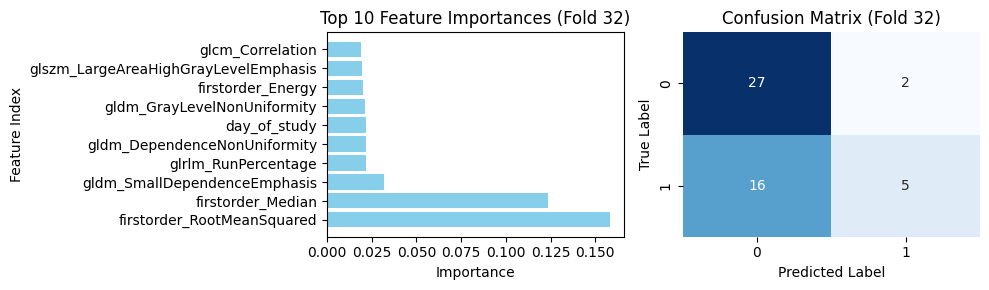


Fold 33:
Original train class distribution: Counter({0: 252, 1: 54})
Original test class distribution: Counter({0: 64, 1: 12})
Best parameters for fold 33: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.8}

Fold 33 results:
Accuracy: 0.7763
F1-macro: 0.6845
F1-micro: 0.7763
F1-weighted: 0.8010
Precision: 0.3913
Recall: 0.7500
ROC AUC: 0.8320
True Positives: 9, False Negatives: 3, False Positives: 14, True Negatives: 50


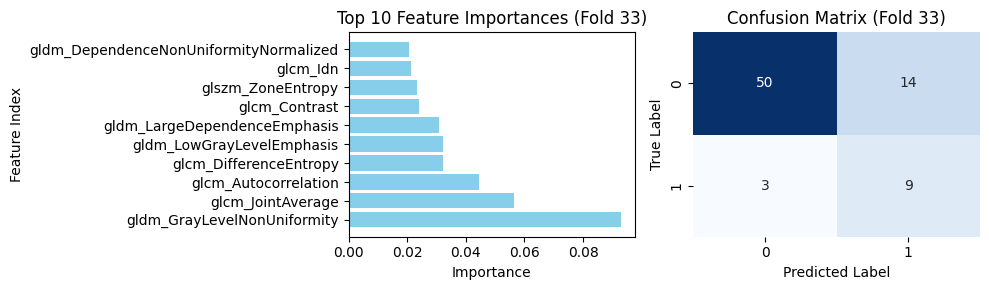


Fold 34:
Original train class distribution: Counter({0: 253, 1: 28})
Original test class distribution: Counter({0: 63, 1: 38})
Best parameters for fold 34: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.7}

Fold 34 results:
Accuracy: 0.6337
F1-macro: 0.4339
F1-micro: 0.6337
F1-weighted: 0.5171
Precision: 0.6667
Recall: 0.0526
ROC AUC: 0.7494
True Positives: 2, False Negatives: 36, False Positives: 1, True Negatives: 62


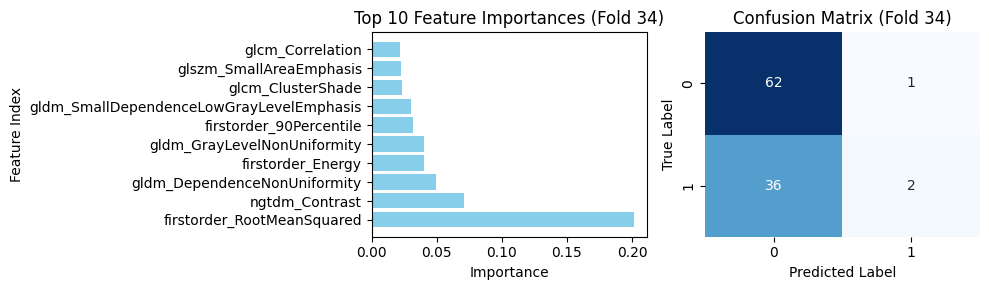


Fold 35:
Original train class distribution: Counter({0: 246, 1: 66})
Original test class distribution: Counter({0: 70})
Best parameters for fold 35: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.8}

Fold 35 results:
Accuracy: 0.8857
F1-macro: 0.4697
F1-micro: 0.8857
F1-weighted: 0.9394
Precision: 0.0000
Recall: 0.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 8, True Negatives: 62


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


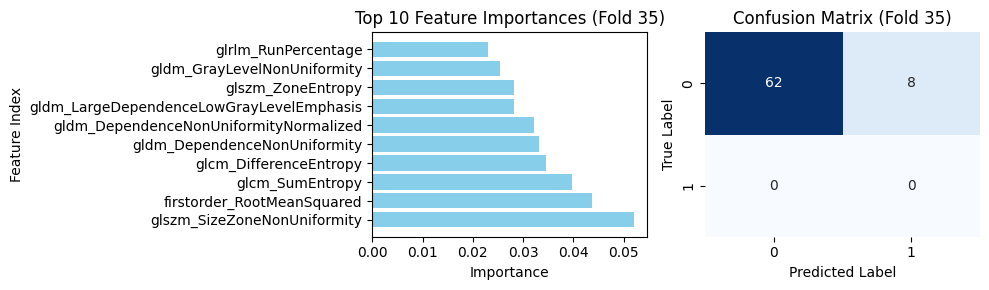


Fold 36:
Original train class distribution: Counter({0: 208, 1: 49})
Original test class distribution: Counter({0: 108, 1: 17})
Best parameters for fold 36: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.7}

Fold 36 results:
Accuracy: 0.7040
F1-macro: 0.4986
F1-micro: 0.7040
F1-weighted: 0.7322
Precision: 0.1429
Recall: 0.2353
ROC AUC: 0.4695
True Positives: 4, False Negatives: 13, False Positives: 24, True Negatives: 84


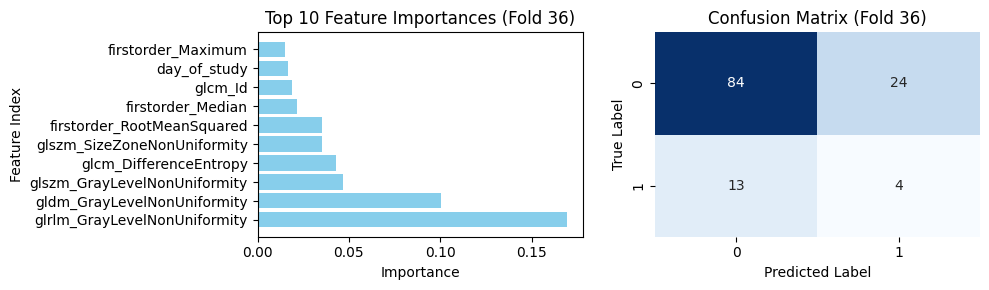


Fold 37:
Original train class distribution: Counter({0: 273, 1: 16})
Original test class distribution: Counter({1: 50, 0: 43})
Best parameters for fold 37: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 37 results:
Accuracy: 0.5699
F1-macro: 0.5419
F1-micro: 0.5699
F1-weighted: 0.5333
Precision: 0.7500
Recall: 0.3000
ROC AUC: 0.6414
True Positives: 15, False Negatives: 35, False Positives: 5, True Negatives: 38


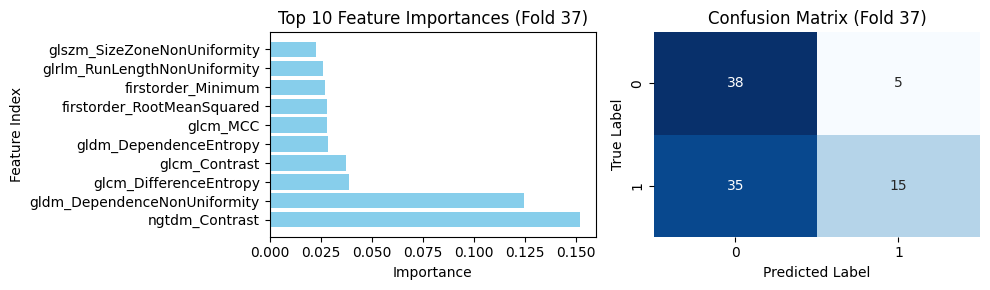


Fold 38:
Original train class distribution: Counter({0: 312, 1: 37})
Original test class distribution: Counter({1: 29, 0: 4})
Best parameters for fold 38: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.8}

Fold 38 results:
Accuracy: 0.1818
F1-macro: 0.1788
F1-micro: 0.1818
F1-weighted: 0.1411
Precision: 1.0000
Recall: 0.0690
ROC AUC: 0.6466
True Positives: 2, False Negatives: 27, False Positives: 0, True Negatives: 4


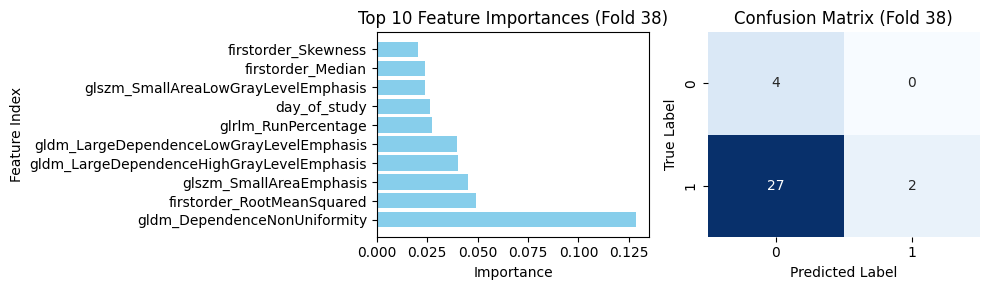


Fold 39:
Original train class distribution: Counter({0: 252, 1: 49})
Original test class distribution: Counter({0: 64, 1: 17})
Best parameters for fold 39: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 39 results:
Accuracy: 0.6790
F1-macro: 0.4387
F1-micro: 0.6790
F1-weighted: 0.6518
Precision: 0.0909
Recall: 0.0588
ROC AUC: 0.4945
True Positives: 1, False Negatives: 16, False Positives: 10, True Negatives: 54


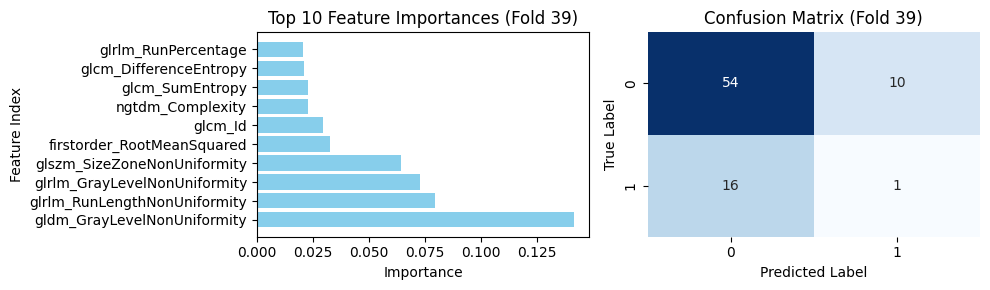


Fold 40:
Original train class distribution: Counter({0: 257, 1: 28})
Original test class distribution: Counter({0: 59, 1: 38})
Best parameters for fold 40: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 500, 'xgbclassifier__subsample': 0.7}

Fold 40 results:
Accuracy: 0.6186
F1-macro: 0.4063
F1-micro: 0.6186
F1-weighted: 0.4831
Precision: 1.0000
Recall: 0.0263
ROC AUC: 0.7944
True Positives: 1, False Negatives: 37, False Positives: 0, True Negatives: 59


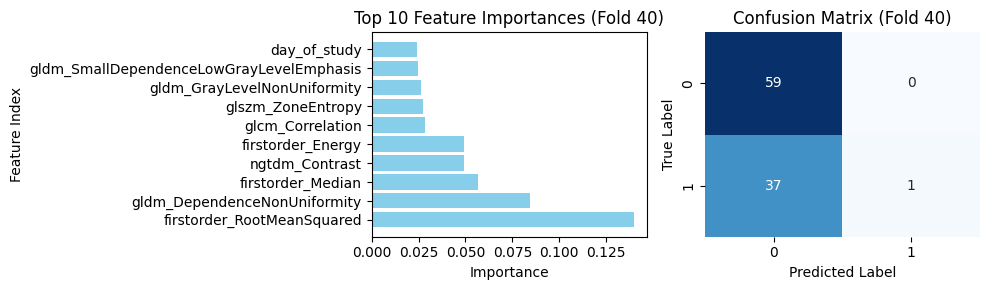


Fold 41:
Original train class distribution: Counter({0: 208, 1: 58})
Original test class distribution: Counter({0: 108, 1: 8})
Best parameters for fold 41: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 41 results:
Accuracy: 0.8103
F1-macro: 0.6013
F1-micro: 0.8103
F1-weighted: 0.8502
Precision: 0.2083
Recall: 0.6250
ROC AUC: 0.8542
True Positives: 5, False Negatives: 3, False Positives: 19, True Negatives: 89


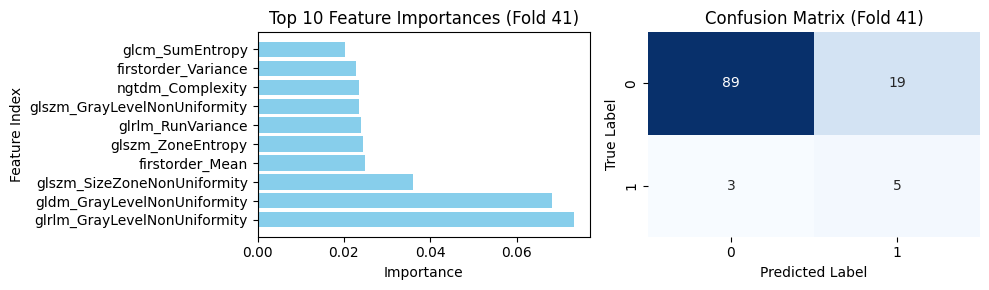


Fold 42:
Original train class distribution: Counter({0: 289, 1: 49})
Original test class distribution: Counter({0: 27, 1: 17})
Best parameters for fold 42: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.7}

Fold 42 results:
Accuracy: 0.6591
F1-macro: 0.4966
F1-micro: 0.6591
F1-weighted: 0.5616
Precision: 1.0000
Recall: 0.1176
ROC AUC: 0.6209
True Positives: 2, False Negatives: 15, False Positives: 0, True Negatives: 27


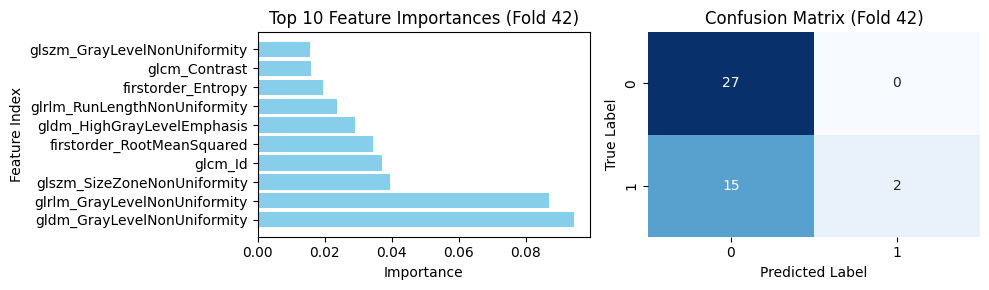


Fold 43:
Original train class distribution: Counter({0: 252, 1: 54})
Original test class distribution: Counter({0: 64, 1: 12})
Best parameters for fold 43: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.7}

Fold 43 results:
Accuracy: 0.8289
F1-macro: 0.7230
F1-micro: 0.8289
F1-weighted: 0.8402
Precision: 0.4706
Recall: 0.6667
ROC AUC: 0.8997
True Positives: 8, False Negatives: 4, False Positives: 9, True Negatives: 55


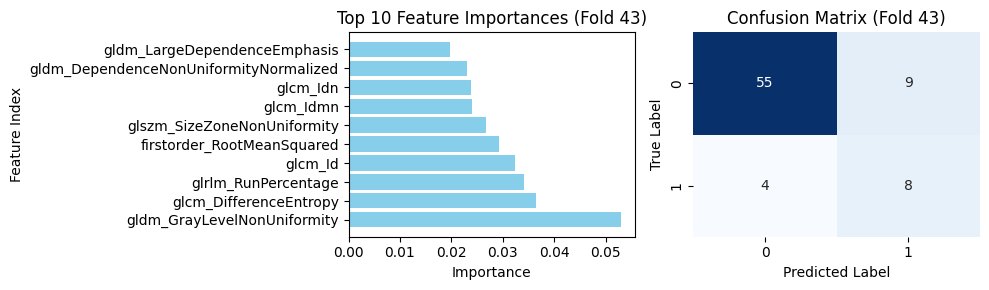


Fold 44:
Original train class distribution: Counter({0: 298, 1: 37})
Original test class distribution: Counter({1: 29, 0: 18})
Best parameters for fold 44: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 44 results:
Accuracy: 0.3191
F1-macro: 0.3114
F1-micro: 0.3191
F1-weighted: 0.2942
Precision: 0.3846
Recall: 0.1724
ROC AUC: 0.4866
True Positives: 5, False Negatives: 24, False Positives: 8, True Negatives: 10


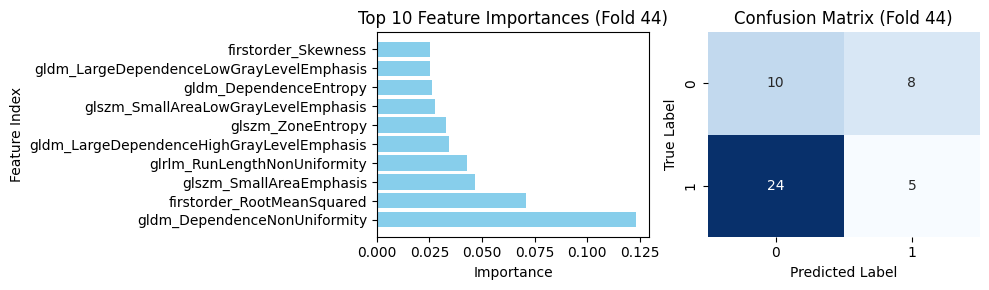


Fold 45:
Original train class distribution: Counter({0: 249, 1: 58})
Original test class distribution: Counter({0: 67, 1: 8})
Best parameters for fold 45: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.8}

Fold 45 results:
Accuracy: 0.7467
F1-macro: 0.4740
F1-micro: 0.7467
F1-weighted: 0.7719
Precision: 0.0769
Recall: 0.1250
ROC AUC: 0.5466
True Positives: 1, False Negatives: 7, False Positives: 12, True Negatives: 55


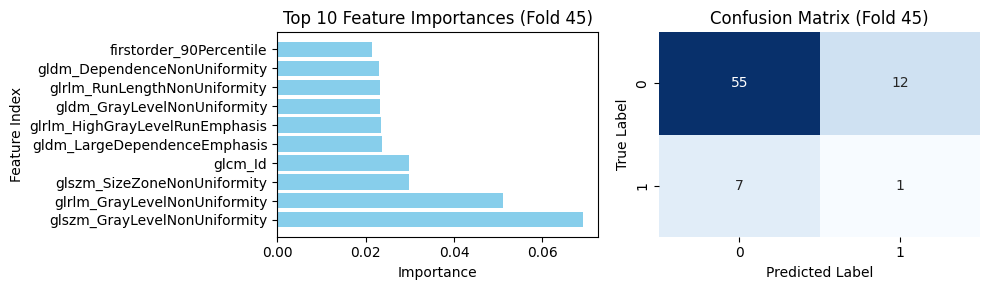


Fold 46:
Original train class distribution: Counter({0: 242, 1: 49})
Original test class distribution: Counter({0: 74, 1: 17})
Best parameters for fold 46: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.7}

Fold 46 results:
Accuracy: 0.6484
F1-macro: 0.4678
F1-micro: 0.6484
F1-weighted: 0.6620
Precision: 0.1429
Recall: 0.1765
ROC AUC: 0.3879
True Positives: 3, False Negatives: 14, False Positives: 18, True Negatives: 56


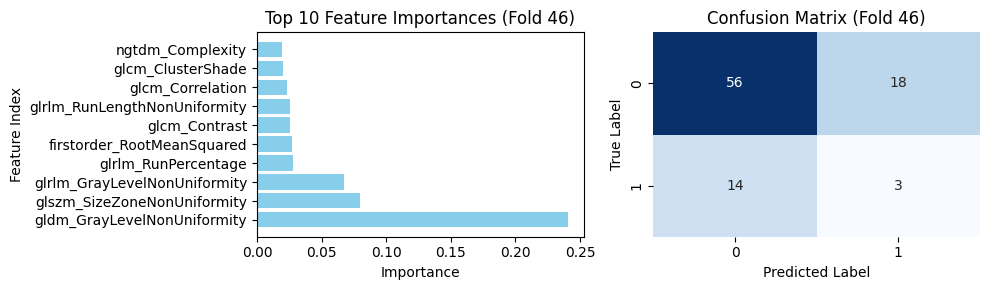


Fold 47:
Original train class distribution: Counter({0: 283, 1: 54})
Original test class distribution: Counter({0: 33, 1: 12})
Best parameters for fold 47: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.8}

Fold 47 results:
Accuracy: 0.8889
F1-macro: 0.8540
F1-micro: 0.8889
F1-weighted: 0.8873
Precision: 0.8182
Recall: 0.7500
ROC AUC: 0.9470
True Positives: 9, False Negatives: 3, False Positives: 2, True Negatives: 31


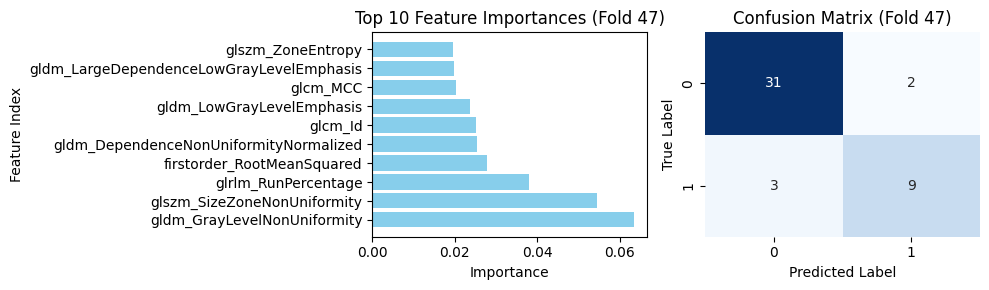


Fold 48:
Original train class distribution: Counter({0: 198, 1: 66})
Original test class distribution: Counter({0: 118})
Best parameters for fold 48: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__subsample': 0.7}

Fold 48 results:
Accuracy: 0.8475
F1-macro: 0.4587
F1-micro: 0.8475
F1-weighted: 0.9174
Precision: 0.0000
Recall: 0.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 18, True Negatives: 100


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


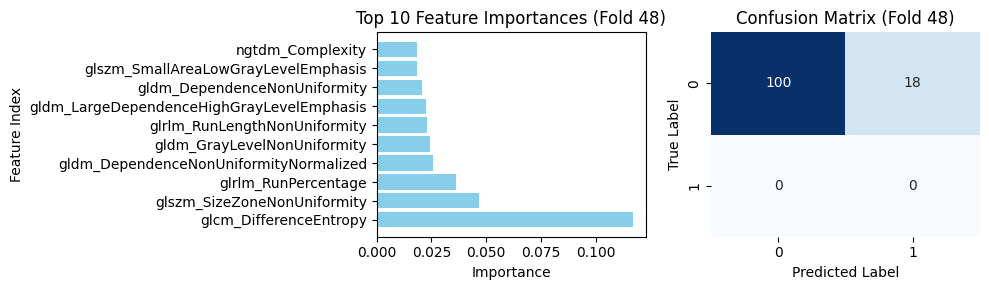


Fold 49:
Original train class distribution: Counter({0: 205, 1: 66})
Original test class distribution: Counter({0: 111})
Best parameters for fold 49: {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 1000, 'xgbclassifier__subsample': 0.7}

Fold 49 results:
Accuracy: 0.8829
F1-macro: 0.4689
F1-micro: 0.8829
F1-weighted: 0.9378
Precision: 0.0000
Recall: 0.0000
ROC AUC: nan
True Positives: 0, False Negatives: 0, False Positives: 13, True Negatives: 98


c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


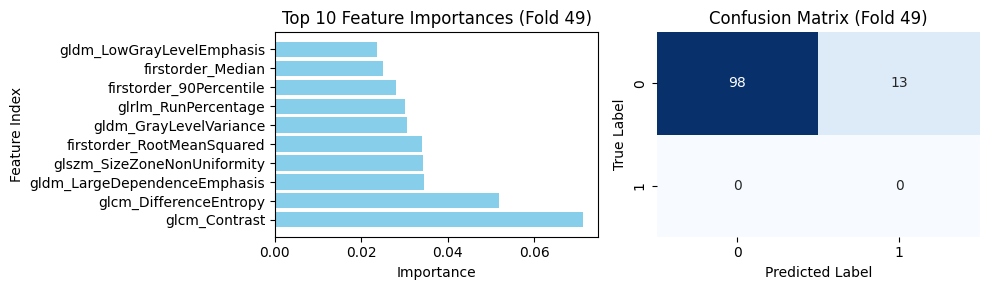


All Folds Completed.

--------------------------------------------------

Summary of Results:



C:\Users\xavie\AppData\Local\Temp\ipykernel_16104\1033265383.py:158: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()  # Adjust layout for better spacing


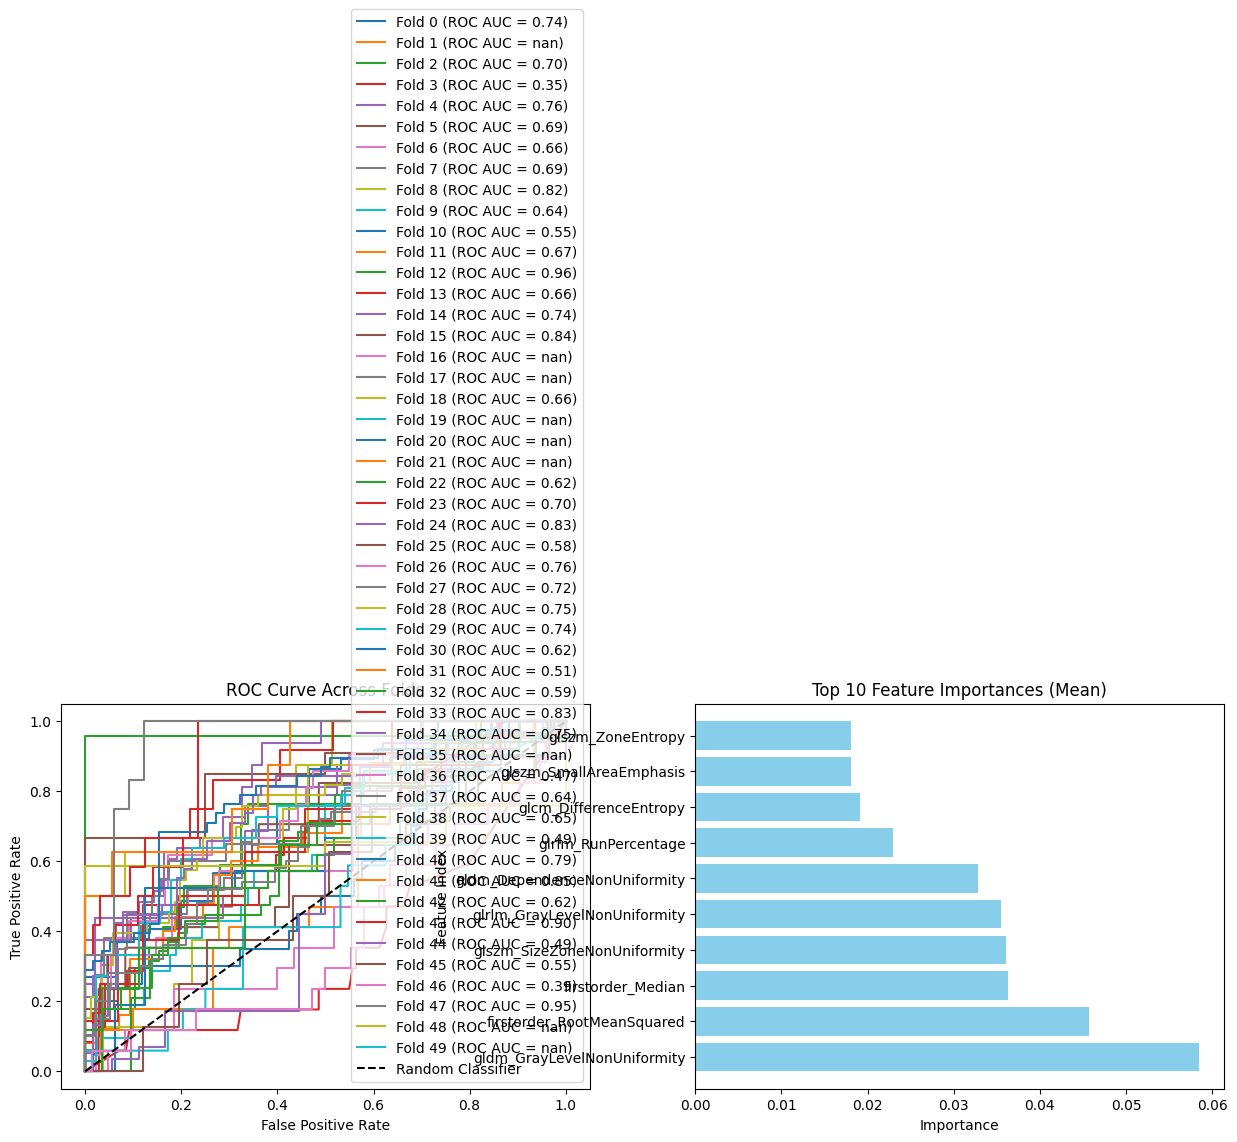


Summary Across Folds:
Mean accuracy: 0.6899
Mean F1-macro: 0.5196
Mean F1-micro: 0.6899
Mean F1-weighted: 0.6928
Mean precision: 0.4414
Mean recall: 0.2522
Mean ROC AUC: nan


In [ ]:
# Track results for each fold
fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_pr_aucs, fold_f1_micros, fold_f1_weighted, feature_importances = [], [], [], [], [], [], [], [], []
class_metrics = {'true_positives': [], 'false_negatives': [], 'false_positives': [], 'true_negatives': []}

# Store ROC and PR curve points for all folds
roc_curves = []
pr_curves = []

split_0_data = next(iter(m_data.values()))
# print(split_0_data['X_train'].columns)

feature_names = split_0_data['X_train'].columns  # This will be a pandas.Index
feature_names = feature_names.str.replace('original_', '', regex=False)

for fold, split_data in m_data.items():
    print(f"\nFold {fold}:")
    print(f"Original train class distribution: {Counter(split_data['y_train'])}")
    print(f"Original test class distribution: {Counter(split_data['y_test'])}")

    model = Pipeline([
        ('scaler', StandardScaler()), 
        ('smote', SMOTE(random_state=SEED)),
        ('xgbclassifier', xgb.XGBClassifier(random_state=SEED)),
    ])

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid_search.fit(split_data['X_train'], split_data['y_train'])

    best_model = grid_search.best_estimator_
    print(f"Best parameters for fold {fold}: {grid_search.best_params_}")

    # Extract feature importances from XGBoost
    xgb_model = best_model.named_steps['xgbclassifier']
    importances = xgb_model.feature_importances_

    # Evaluate on the test set
    preds = best_model.predict(split_data['X_test'])
    preds_proba = best_model.predict_proba(split_data['X_test'])[:, 1]  # Probability for the positive class
    
    # Calculate metrics
    accuracy = accuracy_score(split_data['y_test'], preds)
    f1_macro = f1_score(split_data['y_test'], preds, average='macro')
    f1_micro = f1_score(split_data['y_test'], preds, average='micro')
    f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
    precision = precision_score(split_data['y_test'], preds, zero_division=0)
    recall = recall_score(split_data['y_test'], preds, zero_division=0) 

    fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)

    # precision_c, recall_c, _ = precision_recall_curve(split_data['y_test'], preds_proba, pos_label=1)
    # pr_auc = average_precision_score(split_data['y_test'], preds_proba)
    
    roc_curves.append((fpr, tpr))
    # pr_curves.append((precision_c, recall_c))

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(split_data['y_test'], preds).ravel()

    # Print fold results
    print(f"\nFold {fold} results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"F1-micro: {f1_micro:.4f}")
    print(f"F1-weighted: {f1_weighted:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    # print(f"PR AUC: {pr_auc:.4f}")
    print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
    
    # Plot top k features for this fold
    top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
    top_importances = importances[top_indices]
    # print(top_importances)
    # print(top_indices)
    # print(feature_names[top_indices])

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
    plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
    plt.ylabel("Feature Index")
    plt.xlabel("Importance")
    plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
    # Plot confusion matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(split_data['y_test'], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix (Fold {fold})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # Track results
    fold_accuracies.append(accuracy)
    fold_f1_macros.append(f1_macro)
    fold_f1_micros.append(f1_micro)
    fold_f1_weighted.append(f1_weighted)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_roc_aucs.append(roc_auc)
    feature_importances.append(importances)
    # fold_pr_aucs.append(pr_auc)

    class_metrics['true_positives'].append(tp)
    class_metrics['false_negatives'].append(fn)
    class_metrics['false_positives'].append(fp)
    class_metrics['true_negatives'].append(tn)

print(f"\nAll Folds Completed.")
print("\n--------------------------------------------------")
print("\nSummary of Results:\n")

# print(feature_importances)

# Plotting ROC and Precision-Recall curves side by side
plt.figure(figsize=(15, 5))

# ROC Curve Plot
plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
for i, (fpr, tpr) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.title("ROC Curve Across Folds")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Calculate mean importances across folds
mean_importances = np.mean(feature_importances, axis=0)
# print(mean_importances)
# Get indices of the top k features by mean
top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
top_importances_mean = mean_importances[top_indices_mean]
# print(top_indices_mean)
# print(top_importances_mean)
# print(feature_names[top_indices_mean])

plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
plt.ylabel("Feature Index")
plt.xlabel("Importance")
plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

# Precision-Recall Curve Plot
# plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
# for i, (precision, recall) in enumerate(pr_curves):
#     plt.plot(recall, precision, label=f'Fold {i} (PR AUC = {fold_pr_aucs[i]:.2f})')
# plt.title("Precision-Recall Curve Across Folds")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.legend(loc="lower right")

# Display the plots side by side
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

# Display summary statistics across folds
print(f"\nSummary Across Folds:")
print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
print(f"Mean precision: {np.mean(fold_precisions):.4f}")
print(f"Mean recall: {np.mean(fold_recalls):.4f}")
print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")
# print(f"Mean PR AUC: {np.mean(fold_pr_aucs):.4f}")
